# Synthetic Signal Catalog: Monofractal & Multifractal

Analytical spectra and signal generators for WTMM validation.

- **Cell 1**: Monofractal analytical spectra (fBm, Weierstrass, Lévy)
- **Cell 2**: Monofractal signal examples
- **Cell 3**: Multifractal analytical spectra (Cantor, cascades, Feigenbaum)
- **Cell 4**: Multifractal signal examples
- **Cell 5**: CWT engine imports
- **Cell 6**: Signal selector — set `SIGNAL_NAME` to any label from the catalogs
- **Cells 7–10**: CWT, extrema/chains, partition functions, spectra (all use selected signal)

/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_89508/1308218119.py:7: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.optimize import brentq


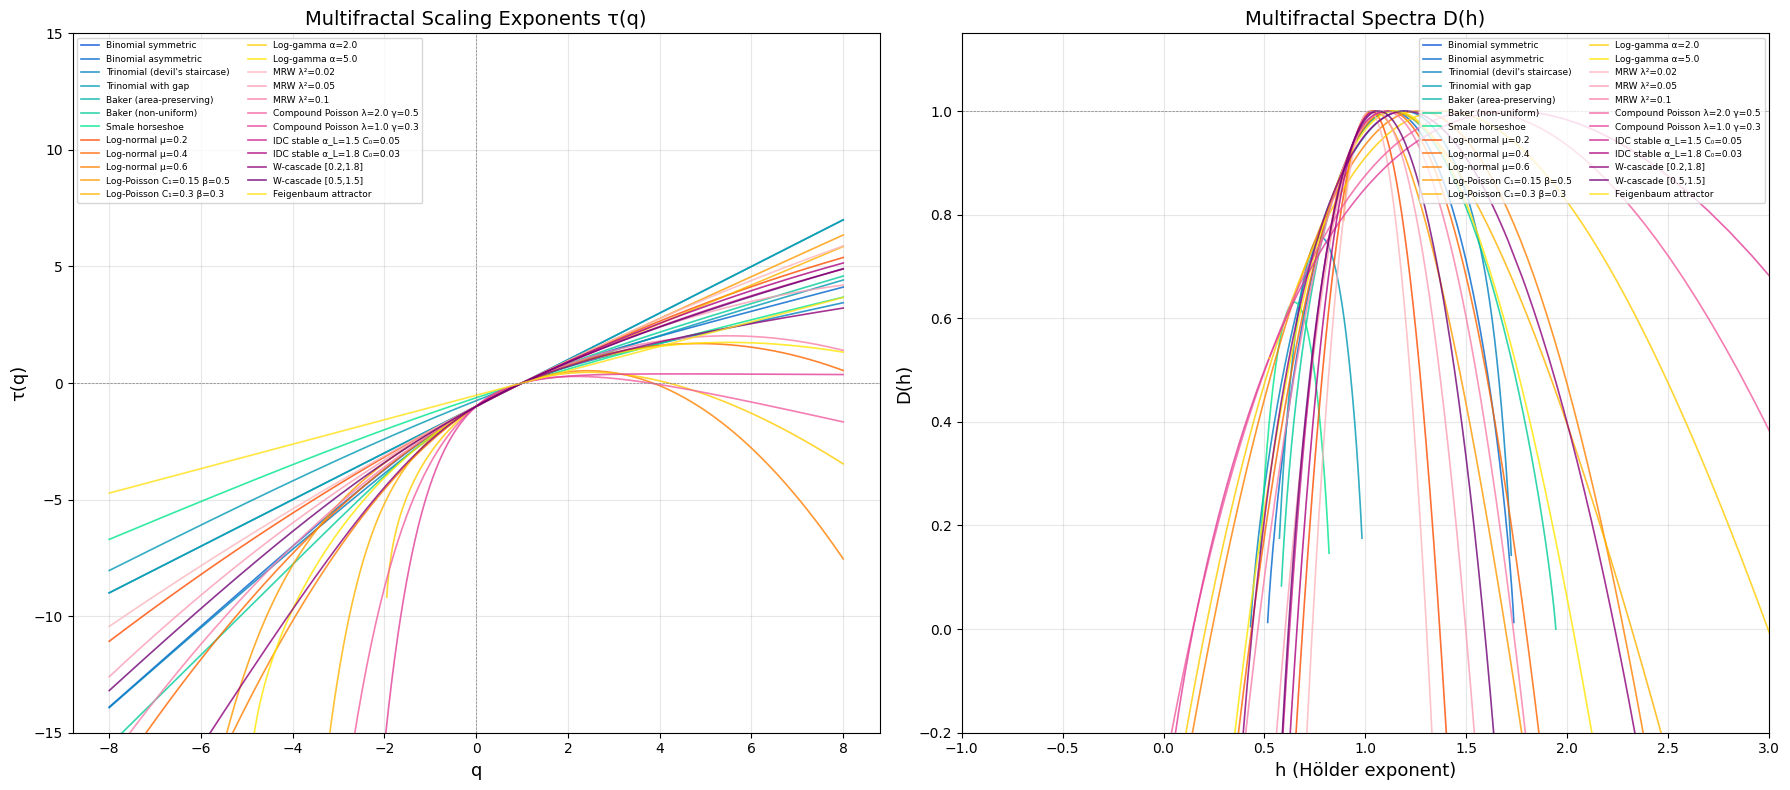


=== Multifractal Verification ===
  Binomial symmetric                        τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.0000
  Binomial asymmetric                       τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.1299
  Trinomial (devil's staircase)             τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.1941
  Trinomial with gap                        τ(0)=-0.7565  τ(1)=-0.0000  D_max=0.7565  h*=0.7795
  Baker (area-preserving)                   τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.0000
  Baker (non-uniform)                       τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.1296
  Smale horseshoe                           τ(0)=-0.6309  τ(1)=-0.0000  D_max=0.6309  h*=0.6501
  Log-normal μ=0.2                          τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.0298
  Log-normal μ=0.4                          τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.1191
  Log-normal μ=0.6                          τ(0)=-1.0001  τ(1)=-0.0001  D_max=0.9999  h*=1.2680
  Log

In [1]:

# ============================================================
# Analytical Spectra Catalog — Part 2: Multifractal Systems
# Cantor measures, cascades, random wavelet cascades, Feigenbaum
# ============================================================

import numpy as np
from scipy.optimize import brentq
from scipy.special import gammaln
import matplotlib.pyplot as plt

q = np.linspace(-8, 8, 500)

multi_catalog = []  # (label, family, q_arr, tau_q, h_q, D_q)

# --- Helpers ---
def legendre(tau, q):
    h = np.gradient(tau, q)
    D = q * h - tau
    return h, D

def cantor_tau(r, p, q_arr):
    """Solve sum(p_i^q * r_i^(-tau)) = 1 for each q."""
    r, p = np.asarray(r, float), np.asarray(p, float)
    tau_out = np.empty_like(q_arr)
    for i, qq in enumerate(q_arr):
        def eq(tau, qq=qq):
            return np.sum(p ** qq * r ** (-tau)) - 1.0
        tau_out[i] = brentq(eq, -50, 50)
    return tau_out

def cascade_tau(q, kind, **params):
    """Unified cascade tau(q) with consistent sign convention.
    All satisfy: tau(0) = -1, tau(1) = 0, concave."""
    if kind == "lognormal":
        C = params["mu"] ** 2 / (2 * np.log(2))
        return (q - 1) * (1 - C * q)
    elif kind == "logpoisson":
        C1, beta = params["C1"], params["beta"]
        return -1 + q + C1 / np.log(beta) * (beta**q - 1 - q * (beta - 1))
    elif kind == "loggamma":
        a = params["alpha"]
        return (q - 1) - (1 / np.log(2)) * (
            gammaln(a + q) - q * gammaln(a + 1) + (q - 1) * gammaln(a)
        )
    elif kind == "compound_poisson":
        lam, gamma = params["lam"], params["gamma"]
        return (q - 1) - lam / np.log(2) * (gamma**q - 1 - q * (gamma - 1))
    elif kind == "idc_stable":
        alpha_l, C0 = params["alpha_l"], params["C0"]
        return (q - 1) - C0 / (np.log(2) * (alpha_l - 1)) * (q**alpha_l - q)

# ===================== A. Multinomial Cantor measures =====================
cantor_specs = [
    ("Binomial symmetric",            [0.5, 0.5],       [0.5, 0.5]),
    ("Binomial asymmetric",           [0.5, 0.5],       [0.7, 0.3]),
    ("Trinomial (devil's staircase)", [0.3, 0.2, 0.5],  [0.2, 0.5, 0.3]),
    ("Trinomial with gap",            [0.4, 0.2, 0.4],  [0.6, 0.0, 0.4]),
]
for label, r, p in cantor_specs:
    mask = np.array(p) > 0
    r_f, p_f = np.array(r)[mask], np.array(p)[mask]
    tau = cantor_tau(r_f, p_f, q)
    h, D = legendre(tau, q)
    multi_catalog.append((label, "cantor", q, tau, h, D))

# ===================== B. Baker's map / Smale horseshoe =====================
baker_specs = [
    ("Baker (area-preserving)", [0.3, 0.7], [0.3, 0.7]),
    ("Baker (non-uniform)",     [0.3, 0.7], [0.5, 0.5]),
    ("Smale horseshoe",         [1/3, 1/3], [0.6, 0.4]),
]
for label, r, p in baker_specs:
    tau = cantor_tau(r, p, q)
    h, D = legendre(tau, q)
    multi_catalog.append((label, "cantor", q, tau, h, D))

# ===================== C. Existing cascades (unified helper) =====================

# Log-normal: μ = 0.2, 0.4, 0.6
for mu in [0.2, 0.4, 0.6]:
    tau_ln = cascade_tau(q, "lognormal", mu=mu)
    h, D = legendre(tau_ln, q)
    multi_catalog.append((f"Log-normal μ={mu}", "cascade", q, tau_ln, h, D))

# Log-Poisson
for C1, beta in [(0.15, 0.5), (0.3, 0.3)]:
    tau_lp = cascade_tau(q, "logpoisson", C1=C1, beta=beta)
    h, D = legendre(tau_lp, q)
    multi_catalog.append((f"Log-Poisson C₁={C1} β={beta}", "cascade", q, tau_lp, h, D))

# Log-gamma (q > -α restriction)
for alpha in [2.0, 5.0]:
    q_lg = np.linspace(-alpha + 0.05, 8, 500)
    tau_lg = cascade_tau(q_lg, "loggamma", alpha=alpha)
    h, D = legendre(tau_lg, q_lg)
    multi_catalog.append((f"Log-gamma α={alpha}", "cascade", q_lg, tau_lg, h, D))

# ===================== D. Random wavelet cascades (NEW) =====================

# --- D1. Multifractal Random Walk (MRW) ---
# Same tau(q) as log-normal but parameterized by λ² (Bacry, Delour, Muzy 2001)
for lam2 in [0.02, 0.05, 0.1]:
    mu_equiv = np.sqrt(2 * lam2 * np.log(2))
    tau_mrw = cascade_tau(q, "lognormal", mu=mu_equiv)
    h, D = legendre(tau_mrw, q)
    multi_catalog.append((f"MRW λ²={lam2}", "wavelet_cascade", q, tau_mrw, h, D))

# --- D2. Compound Poisson cascade (Barral-Mandelbrot) ---
for lam, gamma in [(2.0, 0.5), (1.0, 0.3)]:
    tau_cp = cascade_tau(q, "compound_poisson", lam=lam, gamma=gamma)
    h, D = legendre(tau_cp, q)
    multi_catalog.append((f"Compound Poisson λ={lam} γ={gamma}", "wavelet_cascade",
                          q, tau_cp, h, D))

# --- D3. IDC with stable Lévy measure (Chainais, Riedi, Abry) ---
for alpha_l, C0 in [(1.5, 0.05), (1.8, 0.03)]:
    # q must be > 0 for q^alpha_l when alpha_l is non-integer
    q_idc = np.linspace(0.01, 8, 400)
    tau_idc = cascade_tau(q_idc, "idc_stable", alpha_l=alpha_l, C0=C0)
    h, D = legendre(tau_idc, q_idc)
    multi_catalog.append((f"IDC stable α_L={alpha_l} C₀={C0}", "wavelet_cascade",
                          q_idc, tau_idc, h, D))

# --- D4. W-cascade (Arneodo, Bacry, Muzy) ---
# Uniform multipliers on [a,b], normalized so E[W]=1/2 (conservative dyadic cascade)
# tau(q) = -(1 + log2(E[W'^q])) where W' = W/(a+b) maps [a,b] → [a/(a+b), b/(a+b)]
for a, b in [(0.2, 1.8), (0.5, 1.5)]:
    q_wc = np.linspace(-8, 8, 500)
    # Avoid q = -1 (pole in q+1 denominator)
    q_wc = q_wc[np.abs(q_wc + 1) > 0.05]
    a_n, b_n = a / (a + b), b / (a + b)
    EWq = (b_n**(q_wc + 1) - a_n**(q_wc + 1)) / ((q_wc + 1) * (b_n - a_n))
    tau_wc = -(1 + np.log2(EWq))
    h, D = legendre(tau_wc, q_wc)
    multi_catalog.append((f"W-cascade [{a},{b}]", "wavelet_cascade", q_wc, tau_wc, h, D))

# ===================== E. Feigenbaum attractor =====================
alpha_F = 2.502907875095892
r_feig = [1 / alpha_F**2, 1 / alpha_F]
d_feig = 0.538
p_feig = [r_feig[0]**d_feig, r_feig[1]**d_feig]
p_feig = [pi / sum(p_feig) for pi in p_feig]
tau_feig = cantor_tau(r_feig, p_feig, q)
h, D = legendre(tau_feig, q)
multi_catalog.append(("Feigenbaum attractor", "feigenbaum", q, tau_feig, h, D))

# ===================== PLOTTING =====================
family_colors = {
    "cantor":           plt.cm.winter,        # blues/teals
    "cascade":          plt.cm.autumn,         # reds/oranges
    "wavelet_cascade":  plt.cm.RdPu,           # magentas/pinks
    "feigenbaum":       plt.cm.Wistia,         # standalone
}
family_counts = {}
for _, fam, *_ in multi_catalog:
    family_counts[fam] = family_counts.get(fam, 0) + 1
family_idx = {fam: 0 for fam in family_counts}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

for label, fam, qq, tau, h, D in multi_catalog:
    cmap = family_colors[fam]
    n = family_counts[fam]
    idx = family_idx[fam]
    color = cmap(0.3 + 0.6 * idx / max(n - 1, 1))
    family_idx[fam] = idx + 1

    # Left panel: tau(q)
    ax1.plot(qq, tau, color=color, alpha=0.8, linewidth=1.2, label=label)

    # Right panel: D(h) — multifractal curves
    mask = D > -0.5
    ax2.plot(h[mask], D[mask], color=color, alpha=0.8, linewidth=1.2, label=label)

ax1.set_xlabel('q', fontsize=13)
ax1.set_ylabel('τ(q)', fontsize=13)
ax1.set_title('Multifractal Scaling Exponents τ(q)', fontsize=14)
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.set_ylim(-15, 15)
ax1.legend(fontsize=6.5, ncol=2, loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('h (Hölder exponent)', fontsize=13)
ax2.set_ylabel('D(h)', fontsize=13)
ax2.set_title('Multifractal Spectra D(h)', fontsize=14)
ax2.set_ylim(-0.2, 1.15)
ax2.set_xlim(-1, 3)
ax2.axhline(1, color='gray', linewidth=0.5, linestyle='--')
ax2.legend(fontsize=6.5, ncol=2, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analytical_spectra_multifractal.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================== VERIFICATION =====================
print("\n=== Multifractal Verification ===")
for label, fam, qq, tau, h, D in multi_catalog:
    # Check tau(0) ≈ -1 and tau(1) ≈ 0
    tau_0 = np.interp(0, qq, tau)
    tau_1 = np.interp(1, qq, tau)
    mask = D > 0
    if mask.any():
        Dmax = D[mask].max()
        h_at_max = h[np.argmax(np.where(mask, D, -np.inf))]
        print(f"  {label:40s}  τ(0)={tau_0:+.4f}  τ(1)={tau_1:+.4f}  D_max={Dmax:.4f}  h*={h_at_max:.4f}")
    else:
        print(f"  {label:40s}  τ(0)={tau_0:+.4f}  τ(1)={tau_1:+.4f}  [no positive D region]")

# Cross-checks
print("\n=== Cross-checks ===")
# MRW λ²→0 should be near-monofractal
lam2_small = 0.001
mu_eq = np.sqrt(2 * lam2_small * np.log(2))
tau_test = cascade_tau(q, "lognormal", mu=mu_eq)
h_test, D_test = legendre(tau_test, q)
h_sel = h_test[D_test > 0.5]; h_width = (h_sel.max() - h_sel.min()) if len(h_sel) > 0 else 0
print(f"  MRW λ²=0.001: D(h) width at D>0.5 = {h_width:.6f}  (should be ~0)")

# IDC α_L=2 should match log-normal
tau_idc2 = cascade_tau(q[q > 0.01], "idc_stable", alpha_l=2.0, C0=0.05)
mu_match = np.sqrt(2 * 0.05 * np.log(2))
tau_ln2 = cascade_tau(q[q > 0.01], "lognormal", mu=mu_match)
print(f"  IDC α_L=2 vs log-normal: max|Δτ| = {np.max(np.abs(tau_idc2 - tau_ln2)):.2e}  (should be ~0)")


In [2]:
pip install "setuptools<81"

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Cell 1: Query PKD2 channel inventory and download strain data
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import numpy as np
import matplotlib.pyplot as plt


client = Client("NCEDC")  # BK network served by NCEDC

# Query available channels at PKD2
inv = client.get_stations(network="BK", station="PKD2", level="channel",
                          starttime=UTCDateTime("2003-01-01"),
                          endtime=UTCDateTime("2005-12-31"))

print("Available channels at BK.PKD2:")
print(f"{'Channel':<8} {'Rate (Hz)':<12} {'Azimuth':<10} {'Dip':<8} {'Start':<25} {'End'}")
print("-" * 90)
for net in inv:
    for sta in net:
        for ch in sta:
            print(f"  {ch.code:<8} {ch.sample_rate:<12.4f} {ch.azimuth:<10.1f} {ch.dip:<8.1f} "
                  f"{str(ch.start_date):<25} {ch.end_date}")

# Download strain waveforms around the 2004 Parkfield M6 earthquake
# Start with 1-week test window centered on Sept 28, 2004
t1 = UTCDateTime("2004-08-25")  # 3 days before Parkfield M6
t2 = UTCDateTime("2004-10-05")  # 7 days after

print(f"\nDownloading LQ* channels from {t1} to {t2}...")
try:
    st_strain = client.get_waveforms("BK", "PKD2", "*", "LQ*", t1, t2)
    print(f"Downloaded {len(st_strain)} traces:")
    for tr in st_strain:
        print(f"  {tr.id}  {tr.stats.sampling_rate} Hz  "
              f"{tr.stats.npts} samples  {tr.stats.starttime} - {tr.stats.endtime}")
except Exception as e:
    print(f"LQ* download failed: {e}")
    print("Trying UQ* (lower sample rate)...")
    try:
        st_strain = client.get_waveforms("BK", "PKD2", "*", "UQ*", t1, t2)
        print(f"Downloaded {len(st_strain)} traces:")
        for tr in st_strain:
            print(f"  {tr.id}  {tr.stats.sampling_rate} Hz  "
                  f"{tr.stats.npts} samples  {tr.stats.starttime} - {tr.stats.endtime}")
    except Exception as e2:
        print(f"UQ* also failed: {e2}")
        print("Trying IRIS as fallback...")
        client_iris = Client("IRIS")
        st_strain = client_iris.get_waveforms("BK", "PKD2", "*", "?Q*", t1, t2)
        print(f"Downloaded {len(st_strain)} traces from IRIS")


Available channels at BK.PKD2:
Channel  Rate (Hz)    Azimuth    Dip      Start                     End
------------------------------------------------------------------------------------------
  LEP      1.0000       0.0        0.0      2004-01-15T01:30:00.000000Z 2012-03-02T20:00:00.000000Z
  LQA      1.0000       0.0        0.0      2001-02-08T20:21:00.000000Z 2012-03-02T20:00:00.000000Z
  LQB      1.0000       0.0        0.0      2001-02-08T20:21:00.000000Z 2012-03-02T20:00:00.000000Z
  LQC      1.0000       0.0        0.0      2001-02-08T20:21:00.000000Z 2012-03-02T20:00:00.000000Z
  LQD      1.0000       0.0        0.0      2001-02-08T20:21:00.000000Z 2012-03-02T20:00:00.000000Z
  LQE      1.0000       0.0        0.0      2001-02-08T20:21:00.000000Z 2012-03-02T20:00:00.000000Z
  LQF      1.0000       0.0        0.0      2001-02-08T20:21:00.000000Z 2012-03-02T20:00:00.000000Z
  LQG      1.0000       0.0        0.0      2001-02-08T20:21:00.000000Z 2012-03-02T20:00:00.000000Z
  LQH 

Strain channel metadata:
  LQA: azimuth=0.0°, dip=0.0°, rate=1.0 Hz
  LQB: azimuth=0.0°, dip=0.0°, rate=1.0 Hz
  LQC: azimuth=0.0°, dip=0.0°, rate=1.0 Hz
  LQD: azimuth=0.0°, dip=0.0°, rate=1.0 Hz
  LQE: azimuth=0.0°, dip=0.0°, rate=1.0 Hz
  LQF: azimuth=0.0°, dip=0.0°, rate=1.0 Hz
  LQG: azimuth=0.0°, dip=0.0°, rate=1.0 Hz
  LQH: azimuth=0.0°, dip=0.0°, rate=1.0 Hz
  UQA: azimuth=0.0°, dip=0.0°, rate=0.033333 Hz
  UQB: azimuth=0.0°, dip=0.0°, rate=0.033333 Hz
  UQC: azimuth=0.0°, dip=0.0°, rate=0.033333 Hz
  UQD: azimuth=0.0°, dip=0.0°, rate=0.033333 Hz
  UQE: azimuth=0.0°, dip=0.0°, rate=0.033333 Hz
  UQF: azimuth=0.0°, dip=0.0°, rate=0.033333 Hz
  UQG: azimuth=0.0°, dip=0.0°, rate=0.033333 Hz
  UQH: azimuth=0.0°, dip=0.0°, rate=0.033333 Hz


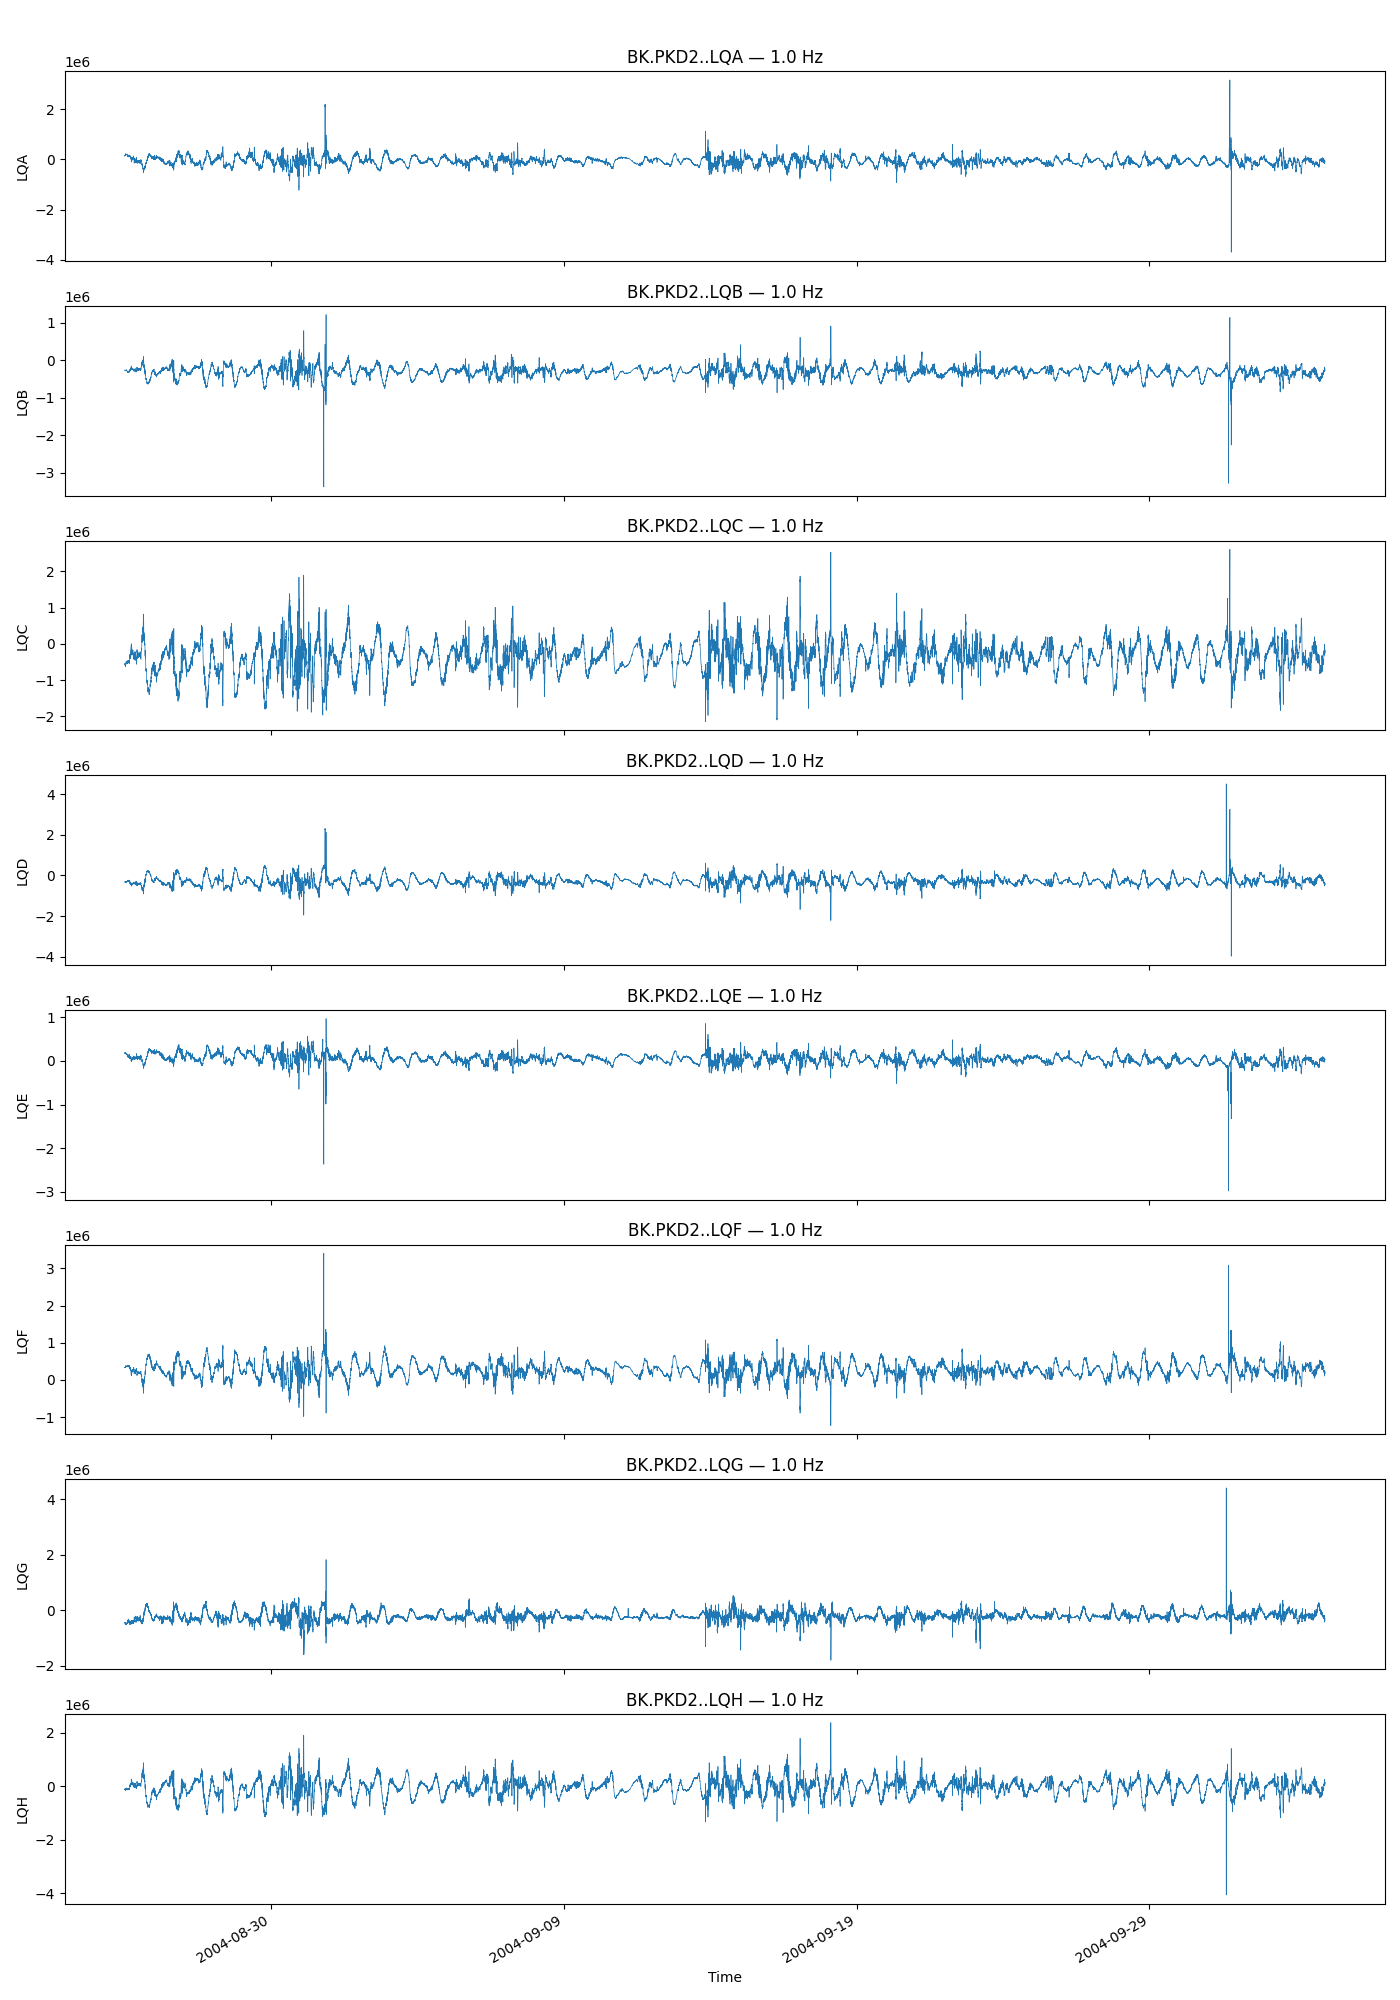

In [30]:
# Cell 2: Identify gauge orientations and plot raw strain data
# Sanity check: tidal signals should be visible in raw strain

# Extract channel metadata from inventory
channel_info = {}
for net in inv:
    for sta in net:
        for ch in sta:
            if ch.code.startswith('LQ') or ch.code.startswith('UQ'):
                channel_info[ch.code] = {
                    'azimuth': ch.azimuth,
                    'dip': ch.dip,
                    'sample_rate': ch.sample_rate,
                    'description': getattr(ch, 'description', ''),
                }

print("Strain channel metadata:")
for code, info in sorted(channel_info.items()):
    print(f"  {code}: azimuth={info['azimuth']}°, dip={info['dip']}°, "
          f"rate={info['sample_rate']} Hz")

# Plot all available strain channels
fig, axes = plt.subplots(len(st_strain), 1, figsize=(14, 2.5 * len(st_strain)), sharex=True)
if len(st_strain) == 1:
    axes = [axes]

for ax, tr in zip(axes, st_strain):
    times = tr.times("matplotlib")
    ax.plot(times, tr.data, linewidth=0.5)
    ax.set_ylabel(tr.id.split('.')[-1])
    ax.set_title(f"{tr.id} — {tr.stats.sampling_rate} Hz")

axes[-1].set_xlabel("Time")
import matplotlib.dates as mdates
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
fig.suptitle("BK.PKD2 Raw Borehole Strain — Parkfield M6 Window", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [31]:
# Cell 12: CWT engine — now imported from wtmm package
from wtmm.cwt import cwtd, cwtd_batched, cwtd_mlx, cwtd_fftw
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
from wtmm.colormaps import lastwave_colormap, lastwave_grey_colormap, lastwave_b2r_colormap, scalogram_lastwave
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit, prange
from numba.typed import List as NumbaList

torch.set_default_dtype(torch.float64)
print(f'PyTorch {torch.__version__}, device: CPU, dtype: float64')


print('CWT engine loaded (from wtmm.cwt). Use cwtd() for faithful per-scale, cwtd_batched() for optimized.')
print(f'CWT device: CPU, dtype: float64')


PyTorch 2.10.0, device: CPU, dtype: float64
CWT engine loaded (from wtmm.cwt). Use cwtd() for faithful per-scale, cwtd_batched() for optimized.
CWT device: CPU, dtype: float64


In [32]:
# ============================================================
# Signal Selector — synthetic catalogs, borehole, OR obspy data
# ============================================================
# Set SIGNAL_NAME to:
#   - any label from mono/multi catalogs
#   - "borehole:<column_name>" to use a borehole curve from df_raw
#   - "obspy:<trace_id>" to use an obspy trace from st_strain
#     e.g. "obspy:BK.PKD2.00.LQE" or "obspy:0" (by index)
#
# INTEGRATE_BOREHOLE: if True, treat borehole signal as a measure
#   density and integrate (cumsum), then normalize so mean = 1.

SIGNAL_NAME = "obspy:0"  # <-- change this (trace id or index)
INTEGRATE_BOREHOLE = True  # cumsum + normalize for borehole data

# --- Lookup signal and theory ---
analysis_signal = None
analysis_label = SIGNAL_NAME
analysis_color = 'k'
is_measure = False
has_theory = False
theory_q = theory_tau = theory_h = theory_D = None

_found = False

# --- Check for obspy signal ---
if SIGNAL_NAME.startswith("obspy:"):
    trace_key = SIGNAL_NAME.split(":", 1)[1].strip()
    
    # Select trace by index or by trace id
    if trace_key.isdigit():
        idx = int(trace_key)
        if idx >= len(st_strain):
            raise ValueError(f"Trace index {idx} out of range. "
                           f"st_strain has {len(st_strain)} traces: "
                           f"{[tr.id for tr in st_strain]}")
        tr = st_strain[idx]
    else:
        matches = st_strain.select(id=trace_key)
        if len(matches) == 0:
            raise ValueError(f"No trace matching '{trace_key}'. "
                           f"Available: {[tr.id for tr in st_strain]}")
        tr = matches[0]
    
    analysis_signal = tr.data.astype(float)
    SIZE = len(analysis_signal)
    analysis_label = f"{tr.id} ({tr.stats.sampling_rate} Hz)"
    analysis_color = 'steelblue'
    has_theory = False
    is_measure = False
    _found = True
    print(f"Using obspy trace: {tr.id}, {tr.stats.npts} samples, "
          f"{tr.stats.sampling_rate} Hz, {tr.stats.starttime} - {tr.stats.endtime}")

# --- Check for borehole signal ---
if not _found and SIGNAL_NAME.startswith("borehole:"):
    col_name = SIGNAL_NAME.split(":", 1)[1].strip()
    if col_name not in df_raw.columns:
        avail = list(df_raw.columns)
        raise ValueError(f"Column '{col_name}' not in df_raw. Available: {avail}")

    raw_sig = df_raw[col_name].dropna().values.astype(float)

    if INTEGRATE_BOREHOLE:
        # Treat as measure density: integrate then normalize so mean = 1
        integrated = np.cumsum(raw_sig)
        analysis_signal = integrated / np.mean(integrated)
        is_measure = True
        analysis_label = f"{well_name}: {col_name} (integrated, normalized)"
    else:
        analysis_signal = raw_sig
        is_measure = False
        analysis_label = f"{well_name}: {col_name}"

    SIZE = len(analysis_signal)
    analysis_color = 'teal'
    has_theory = False
    _found = True

# --- Search multi catalog ---
if not _found:
    for _i, (_label, _fam, _sig) in enumerate(multi_signals):
        if _label == SIGNAL_NAME:
            _cmap = family_colors_sig[_fam]
            _n = family_counts_sig[_fam]
            _idx_before = sum(1 for _l2, _f2, _ in multi_signals[:_i] if _f2 == _fam)
            analysis_color = _cmap(0.3 + 0.6 * _idx_before / max(_n - 1, 1))

            if _fam == 'feigenbaum':
                is_measure = False
                analysis_signal = _sig
            else:
                is_measure = True
                analysis_signal = np.cumsum(_sig)
            SIZE = len(_sig)

            for _tl, _tf, _tq, _ttau, _th, _tD in multi_catalog:
                if _tl == SIGNAL_NAME:
                    has_theory = True
                    theory_q = _tq
                    theory_tau = _ttau
                    theory_h = _th
                    theory_D = _tD
                    break
            _found = True
            break

# --- Search mono catalog ---
if not _found:
    for _i, (_label, _stype, _sig) in enumerate(mono_signals):
        if _label == SIGNAL_NAME:
            _cmap = system_colors_mono[_stype]
            _n = system_counts_mono[_stype]
            _idx_before = sum(1 for _l2, _s2, _ in mono_signals[:_i] if _s2 == _stype)
            analysis_color = _cmap(0.4 + 0.5 * _idx_before / max(_n - 1, 1))

            is_measure = False
            analysis_signal = _sig
            SIZE = len(_sig)

            for _tl, _ts, _tq, _ttau, _h_star, _marker in mono_catalog:
                if _tl == SIGNAL_NAME:
                    has_theory = True
                    theory_q = _tq
                    theory_tau = _ttau
                    theory_h = np.array([_h_star])
                    theory_D = np.array([1.0])
                    break
            _found = True
            break

if analysis_signal is None:
    raise ValueError(f"Signal '{SIGNAL_NAME}' not found.\n"
                     f"Mono: {[l for l,_,_ in mono_signals]}\n"
                     f"Multi: {[l for l,_,_ in multi_signals]}\n"
                     f"Borehole: use 'borehole:<column>' with columns: {list(df_raw.columns)}\n"
                     f"ObsPy: use 'obspy:<index>' or 'obspy:<trace_id>' from st_strain")

# Summary
print(f'Selected: "{analysis_label}"')
print(f'  Signal length: {SIZE}')
print(f'  Is measure (cumsum applied): {is_measure}')
print(f'  Has theoretical spectrum: {has_theory}')
print(f'  Signal range: [{analysis_signal.min():.4f}, {analysis_signal.max():.4f}]')
print(f'  Signal mean: {analysis_signal.mean():.4f}')
if has_theory and theory_h is not None:
    if len(theory_h) == 1:
        print(f'  Monofractal: h* = {theory_h[0]:.4f}')
    else:
        mask = theory_D > 0
        if mask.any():
            print(f'  h range: [{theory_h[mask].min():.4f}, {theory_h[mask].max():.4f}]')

Using obspy trace: BK.PKD2..LQA, 3542400 samples, 1.0 Hz, 2004-08-25T00:00:00.852869Z - 2004-10-04T23:59:59.852869Z
Selected: "BK.PKD2..LQA (1.0 Hz)"
  Signal length: 3542400
  Is measure (cumsum applied): False
  Has theoretical spectrum: False
  Signal range: [-3693044.0000, 3166485.0000]
  Signal mean: -64324.9196


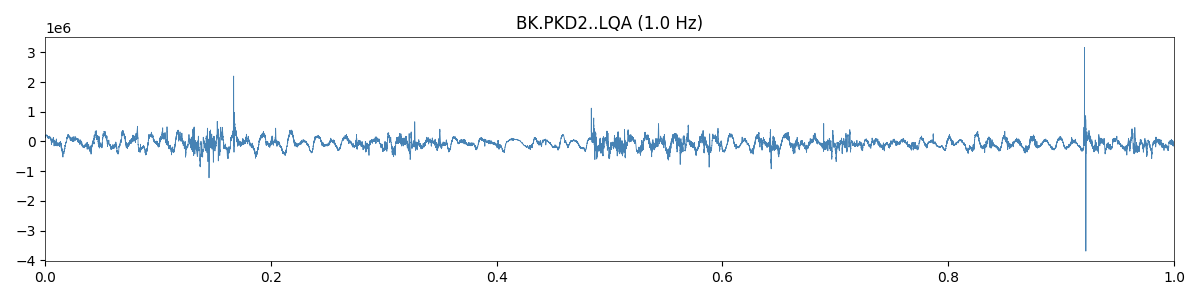

Signal size: 3542400
Signal range: [-3693044.0000, 3166485.0000]
CWT computed in 9.292s  (n_oct=10, n_voice=4, 40 scales)
Coefficients shape: (40, 3542400), Scales: 40 (100.00 to 86107.79)
Valid range at finest scale: (1800, 3540599), coarsest: (1549940, 1992459)


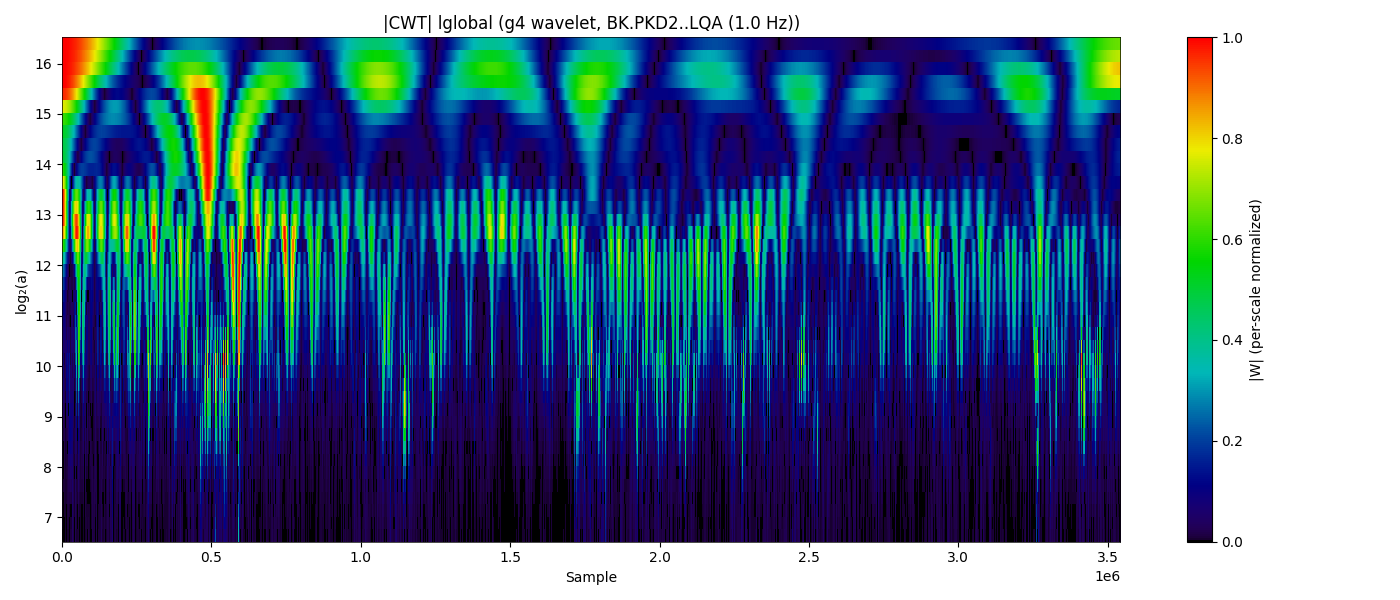

In [34]:
# Cell 13: CWT on selected signal
#SIG_START = 0          # start index                                                                                                                               
#SIG_END = SIZE // 2    # end index (e.g., first half)                                                                                                            
                                                                                                                                                                    
#analysis_signal = analysis_signal[SIG_START:SIG_END]                                                                                                               
#SIZE = len(analysis_signal)


# Select by fractional position (0.0 to 1.0)
FRAC_START = 0.0
FRAC_END = 1

analysis_signal = analysis_signal[int(FRAC_START * SIZE):int(FRAC_END * SIZE)]
SIZE = len(analysis_signal)

# --- CWT parameters (used by all downstream cells) ---
N_OCT = 10
N_VOICE = 4
A_MIN = 100.0
EXPO = -1.0

fig, ax = plt.subplots(figsize=(12, 3))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
t_axis = np.arange(SIZE) / SIZE
ax.plot(t_axis, analysis_signal, color=analysis_color, linewidth=0.6)
ax.set_title(f'{analysis_label}{" (integrated measure)" if is_measure else ""}')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f'Signal size: {SIZE}')
print(f'Signal range: [{analysis_signal.min():.4f}, {analysis_signal.max():.4f}]')

# CWT + visualization
t0 = time.time()
coeffs, scales, valid_ranges = cwtd_fftw(analysis_signal, a_min=A_MIN, n_oct=N_OCT, n_voice=N_VOICE,
                                     wavelet_name='g2', expo=EXPO)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s  (n_oct={N_OCT}, n_voice={N_VOICE}, {len(scales)} scales)')
print(f'Coefficients shape: {coeffs.shape}, Scales: {len(scales)} ({scales[0]:.2f} to {scales[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges[0]}, coarsest: {valid_ranges[-1]}')

# Plot scalogram
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
im = scalogram_lastwave(coeffs, scales=scales, ax=ax,
                        norm_mode='lglobal')
ax.set_title(f'|CWT| lglobal (g4 wavelet, {analysis_label})')
plt.colorbar(im, ax=ax, label='|W| (per-scale normalized)')
plt.tight_layout()
plt.show()


Numba warmup: 0.021s
Total extrema: 33185
Extrema computed in 0.534s
  Scale 0 (a=100.00): 5156 extrema
  Scale 10 (a=565.69): 933 extrema
  Scale 20 (a=3200.00): 169 extrema
  Scale 30 (a=18101.93): 37 extrema
  Scale 39 (a=86107.79): 8 extrema
Chaining: 0.005s
Delete: 1.019s, deleted 19 chains
ChainMax: 0.004s
Total chaining: 1.028s
Remaining extrema: 33164
Pre-deletion chains: 4368
Surviving chains: 4365
Deleted chains: 3


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_89508/3561775510.py:75: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(14, 6))


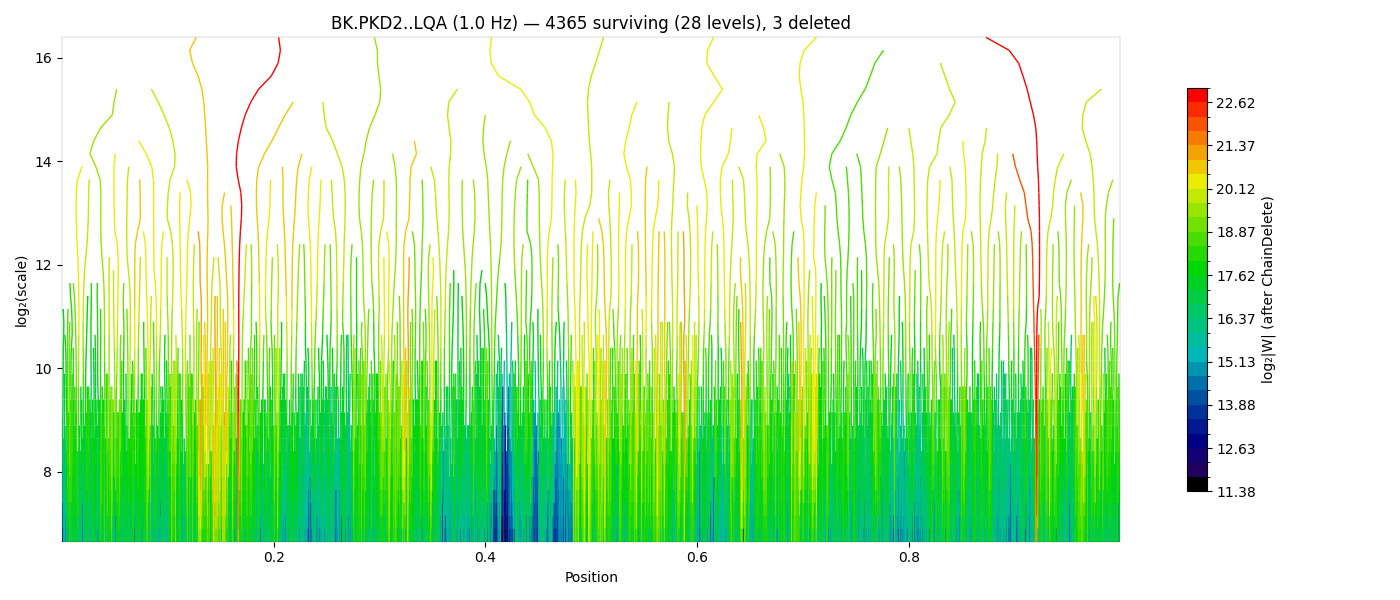

Plot rendered in 1.154s


In [35]:
# Cell 15: Extrema detection — now imported from wtmm package
from wtmm.extrema import compute_extlis_numba, compute_extrep

# Compute extrema representation
dx_signal = 1.0 / SIZE
t0 = time.time()
# Warm up Numba
_ = compute_extlis_numba(coeffs[0], dx_signal, 0.0, 1e-6,
                          valid_ranges[0][0], valid_ranges[0][1])
t_warmup = time.time()
print(f'Numba warmup: {t_warmup - t0:.3f}s')

extrep_abs, extrep_ord, extrep_idx = compute_extrep(
    coeffs, scales, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN,
    valid_ranges=valid_ranges, dx=dx_signal, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t_warmup:.3f}s')
n_total_scales = N_OCT * N_VOICE
for sidx in [0, n_total_scales//4, n_total_scales//2, 3*n_total_scales//4, n_total_scales-1]:
    print(f'  Scale {sidx} (a={scales[sidx]:.2f}): {len(extrep_abs[sidx])} extrema')

# Cell 16: Chaining — now imported from wtmm package
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper, trace_chains, save_chain_state

# Run full chaining pipeline
t0 = time.time()
coarser_links, finer_links = chain_all(extrep_abs, extrep_ord, n_oct=N_OCT, n_voice=N_VOICE)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs, pre_del_ord, pre_del_cl = save_chain_state(extrep_abs, extrep_ord, coarser_links)
pre_del_chains = trace_chains(pre_del_abs, pre_del_ord, pre_del_cl, scales, N_OCT * N_VOICE)

nb_del = chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                           coarser_links, finer_links, n_oct=N_OCT, n_voice=N_VOICE)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

# ChainMax with expo=1
chain_max_wrapper(extrep_ord, coarser_links, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN, expo=0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')
print(f'Total chaining: {t1 - t0:.3f}s')

remaining = sum(len(a) for a in extrep_abs)
print(f'Remaining extrema: {remaining}')

# Cell 17: Extrema representation and maxima lines visualization
from matplotlib.collections import LineCollection
import matplotlib as mpl

DRAW_DELETED = False  # set True to show deleted chains in grey

# Surviving chains (after deletion)
post_del_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, N_OCT * N_VOICE)

# Find which pre-deletion chains were deleted (not present in post-deletion)
surviving_starts = set()
for pos, sv, sign, vals in post_del_chains:
    surviving_starts.add((pos[0], sign))

deleted_chains = []
for pos, sv, sign, vals in pre_del_chains:
    if (pos[0], sign) not in surviving_starts:
        deleted_chains.append((pos, sv, sign, vals))

print(f'Pre-deletion chains: {len(pre_del_chains)}')
print(f'Surviving chains: {len(post_del_chains)}')
print(f'Deleted chains: {len(deleted_chains)}')

t_plot0 = time.time()

N_COLORS = 28
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.1)

# Draw deleted chains (optional, using LineCollection)
if DRAW_DELETED and deleted_chains:
    del_segments = []
    for pos, sv, sign, vals in deleted_chains:
        for j in range(len(pos) - 1):
            del_segments.append([(pos[j], sv[j]), (pos[j+1], sv[j+1])])
    del_lc = LineCollection(del_segments, colors='lightgrey', alpha=0.4, linewidths=0.5)
    ax.add_collection(del_lc)

# Collect all segments + colors for surviving chains in one pass
all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300) for _, _, _, vals in post_del_chains])
vmin, vmax = np.percentile(all_log2_vals, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

segments = []
seg_colors = []
for pos, sv, sign, vals in post_del_chains:
    log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
    for j in range(len(pos) - 1):
        segments.append([(pos[j], sv[j]), (pos[j+1], sv[j+1])])
        seg_colors.append(cmap(norm(log2_v[j])))

lc = LineCollection(segments, colors=seg_colors, linewidths=1)
ax.add_collection(lc)
ax.autoscale()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log\u2082|W| (after ChainDelete)', shrink=0.8)

ax.set_xlabel('Position')
ax.set_ylabel('log\u2082(scale)')
ax.set_title(f'{analysis_label} \u2014 {len(post_del_chains)} surviving ({N_COLORS} levels), {len(deleted_chains)} deleted{"" if not DRAW_DELETED else " (grey)"}')
ax.margins(0)
plt.tight_layout()
plt.show()

t_plot1 = time.time()
print(f'Plot rendered in {t_plot1 - t_plot0:.3f}s')

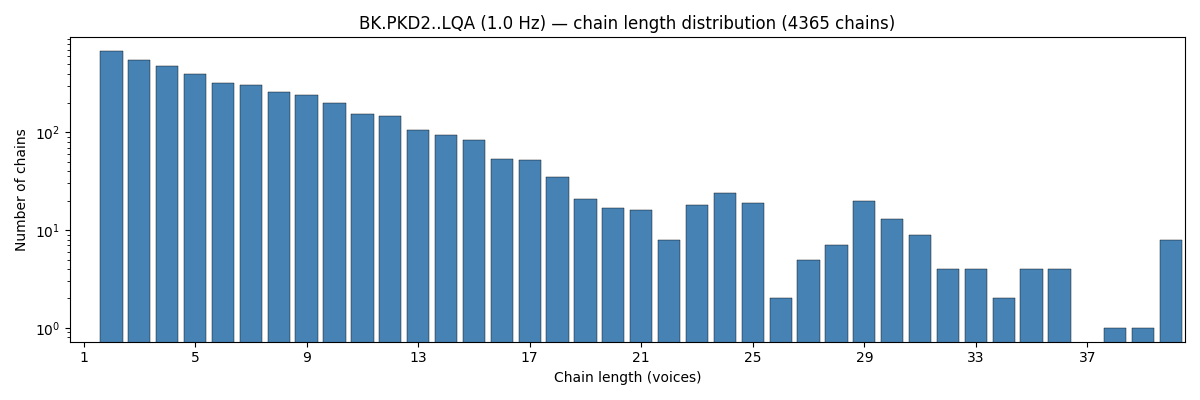

Chain lengths: min=2, max=40, median=6, mean=7.4


In [36]:
# Chain length histogram: number of chains vs. number of voices spanned
chain_lengths = np.array([len(pos) for pos, sv, sign, vals in post_del_chains])

max_len = chain_lengths.max()
voices = np.arange(1, max_len + 1)
counts = np.bincount(chain_lengths, minlength=max_len + 1)[1:]  # skip index 0

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(voices, counts, width=0.8, align='center', color='steelblue', edgecolor='k', linewidth=0.3)
ax.set_yscale('log')
ax.set_xticks(voices[::N_VOICE] if max_len > 20 else voices)
ax.set_xlabel('Chain length (voices)')
ax.set_ylabel('Number of chains')
ax.set_title(f'{analysis_label} — chain length distribution ({len(post_del_chains)} chains)')
ax.set_xlim(0.5, max_len + 0.5)
plt.tight_layout()
plt.show()

print(f'Chain lengths: min={chain_lengths.min()}, max={chain_lengths.max()}, '
      f'median={int(np.median(chain_lengths))}, mean={chain_lengths.mean():.1f}')

Chains passing filter: 20 / 4365 (threshold: log2(a) max 100)


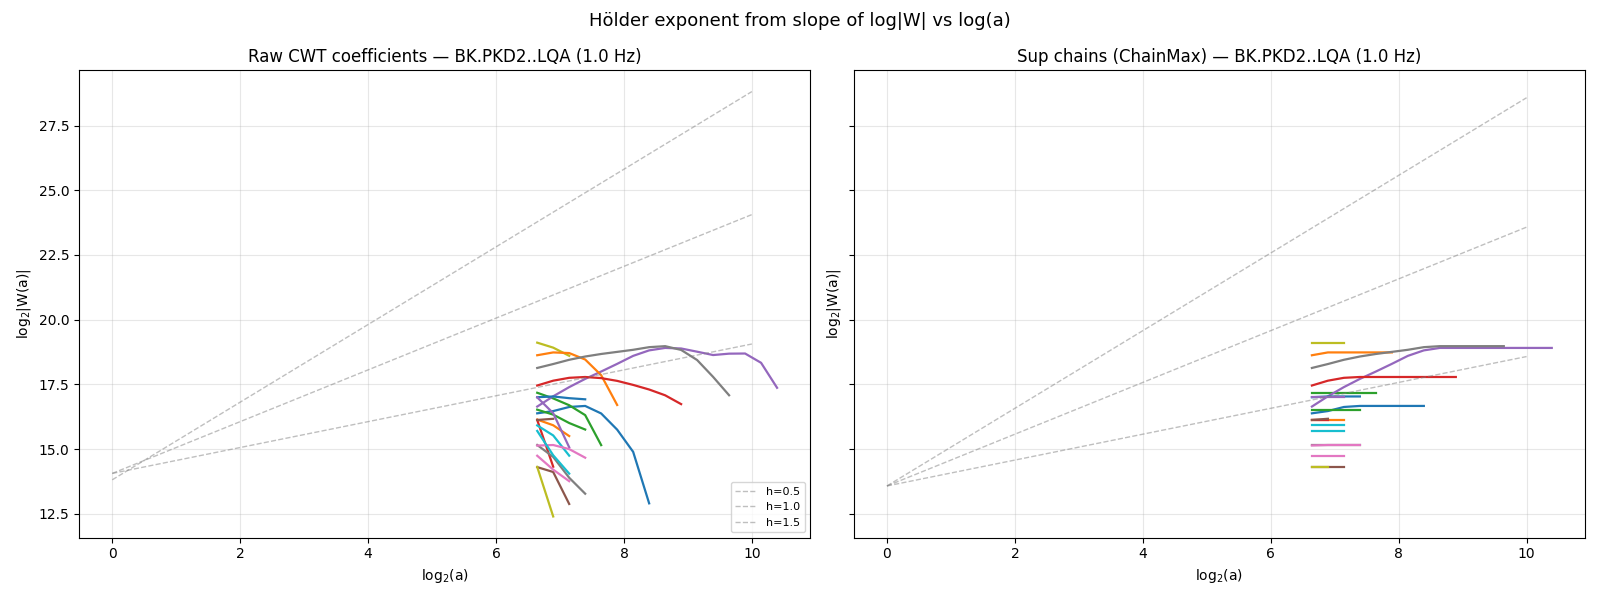

In [38]:
# Hölder exponent visualization: log|W(a)| vs log2(a) for each chain
# Left: raw CWT coefficients along chains
# Right: sup (chainmax) values along chains
# Slope = Hölder exponent h (+ 1/2 for L2 normalization)

SCALE_THRESH = 100       # log2(a) threshold value
SCALE_THRESH_MODE = 'max' # 'min' = chain must reach at least this scale; 'max' = chain must not exceed
MAX_CHAINS_PLOT = 20    # cap to avoid overplotting

# Re-trace chains collecting raw coeffs + chainmax ordinates + scale indices
n_scales_total = N_OCT * N_VOICE
raw_chains = []
sup_chains = []

for fi in range(len(extrep_abs[0])):
    log2_s = []
    raw_vals = []
    sup_vals = []
    cs, ci = 0, fi
    while cs < n_scales_total and ci != -1:
        log2_s.append(np.log2(scales[cs]))
        eidx = extrep_idx[cs][ci]
        raw_vals.append(coeffs[cs, eidx])
        sup_vals.append(extrep_ord[cs][ci])
        ci = coarser_links[cs][ci]
        cs += 1
    if len(log2_s) > 1:
        log2_s = np.array(log2_s)
        raw_log2 = np.log2(np.abs(np.array(raw_vals)) + 1e-300)
        sup_log2 = np.log2(np.abs(np.array(sup_vals)) + 1e-300)
        raw_chains.append((log2_s, raw_log2))
        sup_chains.append((log2_s, sup_log2))

# Filter by scale threshold
filtered_idx = []
for i, (log2_s, _) in enumerate(raw_chains):
    max_scale = log2_s.max()
    min_scale = log2_s.min()
    if SCALE_THRESH_MODE == 'min':
        if max_scale >= SCALE_THRESH:
            filtered_idx.append(i)
    else:  # 'max'
        if max_scale <= SCALE_THRESH:
            filtered_idx.append(i)

# Subsample if too many
if len(filtered_idx) > MAX_CHAINS_PLOT:
    rng = np.random.default_rng(42)
    filtered_idx = sorted(rng.choice(filtered_idx, MAX_CHAINS_PLOT, replace=False))

print(f'Chains passing filter: {len(filtered_idx)} / {len(raw_chains)} '
      f'(threshold: log2(a) {SCALE_THRESH_MODE} {SCALE_THRESH})')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for panel, (ax, chains, title) in enumerate(zip(
        axes,
        [raw_chains, sup_chains],
        ['Raw CWT coefficients', 'Sup chains (ChainMax)'])):
    for i in filtered_idx:
        log2_s, log2_v = chains[i]
        ax.plot(log2_s, log2_v, '-', alpha=1, linewidth=1.6)
    ax.set_xlabel('log$_2$(a)')
    ax.set_ylabel('log$_2$|W(a)|')
    ax.set_title(f'{title} — {analysis_label}')
    ax.grid(True, alpha=0.3)
    # Reference slopes
    for h in [0.5, 1.0, 1.5]:
        x_ref = np.array([0, N_OCT])
        ax.plot(x_ref, h * x_ref + ax.get_ylim()[0] + 2, '--', color='grey',
                alpha=0.5, linewidth=1, label=f'h={h}' if panel == 0 else None)

axes[0].legend(fontsize=8, loc='lower right')
plt.suptitle(f'Hölder exponent from slope of log|W| vs log(a)', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Cell 17b: Cone-of-influence chain filtering
# Remove chains whose finest-scale position falls within the COI
# of the coarsest scale (boundary region where edge effects dominate).

REMOVE_COI_CHAINS = False  # <-- toggle this

if REMOVE_COI_CHAINS:
    # COI boundary from the coarsest scale's valid range
    coarsest_scale_idx = len(scales) - 1
    coi_left_idx, coi_right_idx = valid_ranges[coarsest_scale_idx]
    coi_left_pos = coi_left_idx * dx_signal   # convert index to position
    coi_right_pos = coi_right_idx * dx_signal

    # Find which finest-scale extrema are in the COI
    # (position < coi_left_pos or position > coi_right_pos)
    n_finest = len(extrep_abs[0])
    coi_mask = np.zeros(n_finest, dtype=bool)  # True = in COI, remove
    for fi in range(n_finest):
        pos = extrep_abs[0][fi]
        if pos < coi_left_pos or pos > coi_right_pos:
            coi_mask[fi] = True

    # Walk each COI chain from finest to coarsest, collecting (scale, index) to remove
    remove_set = []  # list of sets, one per scale
    for s in range(len(extrep_abs)):
        remove_set.append(set())

    for fi in range(n_finest):
        if not coi_mask[fi]:
            continue
        cs, ci = 0, fi
        while cs < len(extrep_abs) and ci != -1:
            remove_set[cs].add(ci)
            ci = coarser_links[cs][ci]
            cs += 1

    # Rebuild extrep arrays, removing marked extrema
    # Build index mapping (old -> new) per scale for link fixup
    n_removed_total = 0
    old_to_new = []  # per scale
    for s in range(len(extrep_abs)):
        n_old = len(extrep_abs[s])
        to_remove = remove_set[s]
        n_removed_total += len(to_remove)

        if len(to_remove) == 0:
            old_to_new.append({i: i for i in range(n_old)})
            continue

        keep_mask = np.array([i not in to_remove for i in range(n_old)])
        mapping = {}
        new_idx = 0
        for old_idx in range(n_old):
            if keep_mask[old_idx]:
                mapping[old_idx] = new_idx
                new_idx += 1
            else:
                mapping[old_idx] = -1
        old_to_new.append(mapping)

        extrep_abs[s] = extrep_abs[s][keep_mask]
        extrep_ord[s] = extrep_ord[s][keep_mask]
        extrep_idx[s] = extrep_idx[s][keep_mask]

    # Fix up coarser_links and finer_links with new indices
    for s in range(len(coarser_links)):
        n_cur = len(extrep_abs[s])
        new_cl = np.full(n_cur, -1, dtype=int)
        new_fl = np.full(n_cur, -1, dtype=int)

        old_cl = coarser_links[s]
        old_fl = finer_links[s]
        mapping_cur = old_to_new[s]
        mapping_coarser = old_to_new[s + 1] if s + 1 < len(old_to_new) else {}
        mapping_finer = old_to_new[s - 1] if s > 0 else {}

        for old_idx, new_idx in mapping_cur.items():
            if new_idx == -1:
                continue
            # Coarser link
            if old_idx < len(old_cl):
                old_target = old_cl[old_idx]
                if old_target != -1 and old_target in mapping_coarser:
                    new_cl[new_idx] = mapping_coarser[old_target]
                else:
                    new_cl[new_idx] = -1
            # Finer link
            if old_idx < len(old_fl):
                old_target = old_fl[old_idx]
                if old_target != -1 and old_target in mapping_finer:
                    new_fl[new_idx] = mapping_finer[old_target]
                else:
                    new_fl[new_idx] = -1

        coarser_links[s] = new_cl
        finer_links[s] = new_fl

    n_coi_chains = int(coi_mask.sum())
    n_remaining = sum(len(a) for a in extrep_abs)
    print(f'COI filtering: removed {n_coi_chains} chains ({n_removed_total} extrema across all scales)')
    print(f'  COI boundary (coarsest scale): position [{coi_left_pos:.4f}, {coi_right_pos:.4f}]')
    print(f'  COI boundary (indices): [{coi_left_idx}, {coi_right_idx}] of {SIZE}')
    print(f'  Remaining extrema: {n_remaining}')

    # Re-trace surviving chains for visualization
    post_coi_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, N_OCT * N_VOICE)
    print(f'  Surviving chains after COI filter: {len(post_coi_chains)}')

    # Visualization: show COI boundaries on maxima lines
    import matplotlib as mpl
    N_COLORS = 14
    fig, ax = plt.subplots(figsize=(14, 6))
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

    # COI shading
    ax.axvspan(0, coi_left_pos, color='red', alpha=0.08, label='COI (removed)')
    ax.axvspan(coi_right_pos, 1.0, color='red', alpha=0.08)

    # Surviving chains colored by log2|ordinate|
    if len(post_coi_chains) > 0:
        all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300)
                                        for _, _, _, vals in post_coi_chains])
        vmin, vmax = np.percentile(all_log2_vals, [0, 100])
        boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
        norm_c = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
        cmap_c = lastwave_colormap(N_COLORS)
        for pos, sv, sign, vals in post_coi_chains:
            log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
            for j in range(len(pos) - 1):
                ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap_c(norm_c(log2_v[j])), lw=1)

    ax.set_xlabel('Position')
    ax.set_ylabel('log₂(scale)')
    ax.set_title(f'{analysis_label} — {len(post_coi_chains)} chains after COI filter '
                 f'({n_coi_chains} removed)')
    ax.legend(fontsize=8, loc='upper right')
    ax.margins(0)
    plt.tight_layout()
    plt.show()
else:
    print('COI filtering: disabled (REMOVE_COI_CHAINS = False)')


COI filtering: disabled (REMOVE_COI_CHAINS = False)


In [16]:
# Cell 20: Optimal regression range search
# Grid search over (log2_a_min, log2_a_max) to find the range that:
#   1. Best internal R² — how linear are T(q,a) vs log2(a) within the range
#   2. Best theory fit — how close are the resulting tau(q) to analytical values
#   3. Best D(h) spectrum — per-q D(h) match and spectrum width agreement

LOG2_A_MIN = .1
LOG2_A_MAX = 4
from wtmm.partition import pf_get_T
from wtmm.partition import pf_get_T, pf_get_H, pf_get_D
from wtmm.spectra import compute_spectra

log2_a = pf['log2_a']
n_voice = pf['n_voice']
log2_a0 = np.log2(pf['a_min'])
dx = 1.0 / n_voice
max_idx = pf['index_max']

# Build grid: all (min, max) pairs with at least 1 octave separation
min_octave_span = 1.0
grid_step = dx  # step in log2(a) units

lo_vals = np.arange(log2_a0, log2_a0 + dx * max_idx - min_octave_span + dx/2, grid_step)
hi_vals = np.arange(log2_a0 + min_octave_span, log2_a0 + dx * max_idx + dx/2, grid_step)

q_array = pf['q_list']
n_q = len(q_array)

# Precompute T(q,a), H(q,a), D(q,a) for all q
T_all = np.zeros((n_q, max_idx + 1))
H_all = np.zeros((n_q, max_idx + 1))
D_all = np.zeros((n_q, max_idx + 1))
for qi in range(n_q):
    T_all[qi] = pf_get_T(pf, qi, 'extensive')[:max_idx + 1]
    H_all[qi] = pf_get_H(pf, qi, 'extensive')[:max_idx + 1]
    D_all[qi] = pf_get_D(pf, qi, q_array[qi], 'extensive')[:max_idx + 1]

# Theory values at the partition function q values (if available)
is_multifractal_theory = has_theory and theory_h is not None and len(theory_h) > 1
if has_theory:
    tau_theory_at_q = np.interp(q_array, theory_q, theory_tau)
if is_multifractal_theory:
    h_theory_at_q = np.interp(q_array, theory_q, theory_h)
    D_theory_at_q = np.interp(q_array, theory_q, theory_D)
    # Theory spectrum width: range of h where D > 0
    _tmask = theory_D > 0
    theory_width = theory_h[_tmask].max() - theory_h[_tmask].min() if _tmask.any() else 0.0

results = []  # (lo, hi, mean_r2, tau_rmse, dh_score)

for lo in lo_vals:
    idx_lo = int(round((lo - log2_a0) / dx))
    idx_lo = max(idx_lo, 0)
    for hi in hi_vals:
        if hi - lo < min_octave_span - 1e-9:
            continue
        idx_hi = int(round((hi - log2_a0) / dx))
        idx_hi = min(idx_hi, max_idx)
        if idx_hi - idx_lo < 2:
            continue

        vidx = np.arange(idx_lo, idx_hi + 1)
        x = log2_a0 + dx * vidx

        # Compute R² and slopes for T, H, D
        r2_list = []
        tau_fit = np.full(n_q, np.nan)
        h_fit = np.full(n_q, np.nan)
        d_fit = np.full(n_q, np.nan)
        for qi in range(n_q):
            y_T = T_all[qi, vidx]
            y_H = H_all[qi, vidx]
            y_D = D_all[qi, vidx]
            if not np.all(np.isfinite(y_T)):
                continue
            slope_T, intercept_T = np.polyfit(x, y_T, 1)
            tau_fit[qi] = slope_T
            y_pred = slope_T * x + intercept_T
            ss_res = np.sum((y_T - y_pred)**2)
            ss_tot = np.sum((y_T - np.mean(y_T))**2)
            r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
            r2_list.append(r2)
            if np.all(np.isfinite(y_H)):
                h_fit[qi] = np.polyfit(x, y_H, 1)[0]
            if np.all(np.isfinite(y_D)):
                d_fit[qi] = np.polyfit(x, y_D, 1)[0]

        if len(r2_list) == 0:
            continue
        mean_r2 = np.mean(r2_list)

        # Theory tau RMSE
        if has_theory:
            vm = np.isfinite(tau_fit)
            tau_rmse = np.sqrt(np.mean((tau_fit[vm] - tau_theory_at_q[vm])**2)) if vm.any() else np.inf
        else:
            tau_rmse = np.nan

        # D(h) spectrum score: per-q comparison of (h(q), D(q)) pairs
        if is_multifractal_theory:
            vm = np.isfinite(h_fit) & np.isfinite(d_fit)
            if vm.sum() >= 3:
                # Per-q h(q) RMSE
                h_rmse = np.sqrt(np.mean((h_fit[vm] - h_theory_at_q[vm])**2))
                # Per-q D(q) RMSE
                d_rmse = np.sqrt(np.mean((d_fit[vm] - D_theory_at_q[vm])**2))
                # Spectrum width comparison
                wtmm_width = h_fit[vm].max() - h_fit[vm].min()
                width_error = abs(wtmm_width - theory_width) / max(theory_width, 1e-10)
                # Combined score: geometric mean of normalized errors
                dh_score = np.sqrt(h_rmse**2 + d_rmse**2 + (width_error * 0.5)**2)
            else:
                dh_score = np.inf
        else:
            dh_score = np.nan

        results.append((lo, hi, mean_r2, tau_rmse, dh_score))

results = np.array(results)

# --- Find best ranges ---
# 1. Best R²
best_r2_idx = np.argmax(results[:, 2])
best_r2 = results[best_r2_idx]
print(f'Best internal R²:')
print(f'  Range: log2(a) = [{best_r2[0]:.2f}, {best_r2[1]:.2f}]  '
      f'({best_r2[1]-best_r2[0]:.1f} octaves)')
print(f'  Mean R² = {best_r2[2]:.6f}')

if has_theory:
    # 2. Best theory tau fit
    best_thy_idx = np.argmin(results[:, 3])
    best_thy = results[best_thy_idx]
    print(f'\nBest tau(q) theory fit:')
    print(f'  Range: log2(a) = [{best_thy[0]:.2f}, {best_thy[1]:.2f}]  '
          f'({best_thy[1]-best_thy[0]:.1f} octaves)')
    print(f'  tau(q) RMSE = {best_thy[3]:.6f}, R² = {best_thy[2]:.6f}')

    # 3. Combined: best theory fit among ranges with R² > 0.99
    good_r2_mask = results[:, 2] > 0.99
    if good_r2_mask.any():
        good_results = results[good_r2_mask]
        best_combo_idx = np.argmin(good_results[:, 3])
        best_combo = good_results[best_combo_idx]
        print(f'\nBest combined (R²>0.99, then min tau RMSE):')
        print(f'  Range: log2(a) = [{best_combo[0]:.2f}, {best_combo[1]:.2f}]  '
              f'({best_combo[1]-best_combo[0]:.1f} octaves)')
        print(f'  tau(q) RMSE = {best_combo[3]:.6f}, R² = {best_combo[2]:.6f}')

if is_multifractal_theory:
    # 4. Best D(h) spectrum match
    best_dh_idx = np.argmin(results[:, 4])
    best_dh = results[best_dh_idx]
    print(f'\nBest D(h) spectrum fit:')
    print(f'  Range: log2(a) = [{best_dh[0]:.2f}, {best_dh[1]:.2f}]  '
          f'({best_dh[1]-best_dh[0]:.1f} octaves)')
    print(f'  D(h) score = {best_dh[4]:.6f} (lower=better)')
    print(f'  R² = {best_dh[2]:.6f}, tau RMSE = {best_dh[3]:.6f}')

    # Best D(h) among good R² ranges
    if good_r2_mask.any():
        best_dh_combo_idx = np.argmin(good_results[:, 4])
        best_dh_combo = good_results[best_dh_combo_idx]
        print(f'\nBest D(h) (R²>0.99):')
        print(f'  Range: log2(a) = [{best_dh_combo[0]:.2f}, {best_dh_combo[1]:.2f}]  '
              f'({best_dh_combo[1]-best_dh_combo[0]:.1f} octaves)')
        print(f'  D(h) score = {best_dh_combo[4]:.6f}, R² = {best_dh_combo[2]:.6f}')

print(f'\nCurrent setting: LOG2_A_MIN={LOG2_A_MIN}, LOG2_A_MAX={LOG2_A_MAX}')

# --- Visualization ---
n_panels = 1 + (1 if has_theory else 0) + (1 if is_multifractal_theory else 0)
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

# Reshape for heatmaps
lo_unique = np.sort(np.unique(results[:, 0]))
hi_unique = np.sort(np.unique(results[:, 1]))
lo_to_i = {v: i for i, v in enumerate(lo_unique)}
hi_to_j = {v: j for j, v in enumerate(hi_unique)}

r2_grid = np.full((len(lo_unique), len(hi_unique)), np.nan)
rmse_grid = np.full((len(lo_unique), len(hi_unique)), np.nan)
dh_grid = np.full((len(lo_unique), len(hi_unique)), np.nan)
for row in results:
    lo, hi, r2, rmse, dh = row
    i, j = lo_to_i[lo], hi_to_j[hi]
    r2_grid[i, j] = r2
    rmse_grid[i, j] = rmse
    dh_grid[i, j] = dh

extent = [hi_unique[0], hi_unique[-1], lo_unique[0], lo_unique[-1]]
panel = 0

# Panel 1: R² heatmap
ax = axes[panel]
im = ax.imshow(r2_grid, aspect='auto', origin='lower', extent=extent,
               cmap='RdYlGn', vmin=np.nanpercentile(r2_grid, 5), vmax=1.0)
ax.plot(best_r2[1], best_r2[0], 'k*', markersize=15, label='Best R²')
ax.set_xlabel('log₂(a) max'); ax.set_ylabel('log₂(a) min')
ax.set_title('Mean R² of T(q,a) regressions')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax)
panel += 1

# Panel 2: tau(q) RMSE
if has_theory:
    ax = axes[panel]
    vmax_rmse = np.nanpercentile(rmse_grid, 90)
    im2 = ax.imshow(rmse_grid, aspect='auto', origin='lower', extent=extent,
                    cmap='RdYlGn_r', vmin=0, vmax=vmax_rmse)
    ax.plot(best_thy[1], best_thy[0], 'k*', markersize=15, label='Best τ(q)')
    if good_r2_mask.any():
        ax.plot(best_combo[1], best_combo[0], 'b^', markersize=12, label='Best combo')
    ax.set_xlabel('log₂(a) max'); ax.set_ylabel('log₂(a) min')
    ax.set_title('τ(q) RMSE vs theory')
    ax.legend(fontsize=8)
    plt.colorbar(im2, ax=ax)
    panel += 1

# Panel 3: D(h) spectrum score
if is_multifractal_theory:
    ax = axes[panel]
    vmax_dh = np.nanpercentile(dh_grid, 90)
    im3 = ax.imshow(dh_grid, aspect='auto', origin='lower', extent=extent,
                    cmap='RdYlGn_r', vmin=0, vmax=vmax_dh)
    ax.plot(best_dh[1], best_dh[0], 'k*', markersize=15, label='Best D(h)')
    if good_r2_mask.any():
        ax.plot(best_dh_combo[1], best_dh_combo[0], 'b^', markersize=12, label='Best D(h) R²>0.99')
    ax.set_xlabel('log₂(a) max'); ax.set_ylabel('log₂(a) min')
    ax.set_title('D(h) spectrum score\n(per-q h & D RMSE + width)')
    ax.legend(fontsize=8)
    plt.colorbar(im3, ax=ax)

plt.tight_layout()
plt.show()

NameError: name 'pf' is not defined

In [17]:
# Interactive scale range selector
# Drag the red/blue vertical lines on the T(q,a) panel to change
# the regression range. Spectra update on mouse release.
# Press 'm' to toggle canonical/microcanonical method.
%matplotlib widget
from wtmm.interactive import interactive_spectra

fig_int, state = interactive_spectra(pf, method='canonical')


NameError: name 'pf' is not defined

Partition function computed in 0.007s, up to scale index 39
Extrema per scale (sample): [5156 4365 3688 3133 2661]...[14 10 10  9  8]


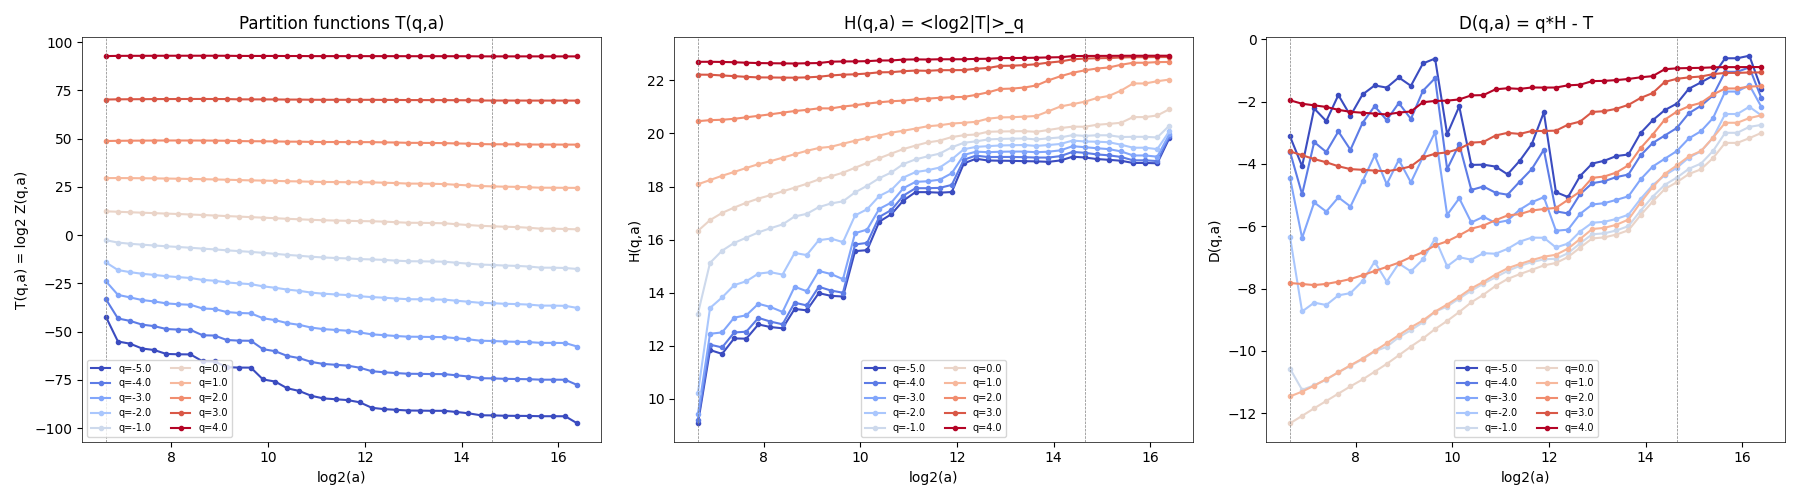

Gray dashed lines show regression range [log2(a)=6.64 to 14.64]


In [50]:
# Cell 18: Partition function — now imported from wtmm package
from wtmm.partition import compute_partition_function, pf_get_T, pf_get_H, pf_get_D
LOG2_A_MIN = 6.64
LOG2_A_MAX = 14.64

# Compute partition function
q_list = np.arange(-5, 5, 1)  #[-5, -3, -1, -.5, -.25, 0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75,  2]#np.arange(-.5, 1.5, .1) 

t0 = time.time()
pf = compute_partition_function(extrep_ord, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN, q_list=q_list)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf["index_max"]}')
print(f'Extrema per scale (sample): {pf["n_ext"][:5]}...{pf["n_ext"][-5:]}')

# Plot T(q,a) = log2(Z(q,a)) vs log2(a)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
log2_a = pf['log2_a']
valid = slice(0, pf['index_max'] + 1)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_list)))

# T(q,a)
ax = axes[0]
for i, q in enumerate(pf['q_list']):
    y = pf_get_T(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) = log2 Z(q,a)')
ax.set_title('Partition functions T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)

# H(q,a)
ax = axes[1]
for i, q in enumerate(pf['q_list']):
    y = pf_get_H(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)

# D(q,a)
ax = axes[2]
for i, q in enumerate(pf['q_list']):
    y = pf_get_D(pf, i, q)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)

plt.tight_layout()
plt.show()
print(f'Gray dashed lines show regression range [log2(a)={LOG2_A_MIN} to {LOG2_A_MAX}]')


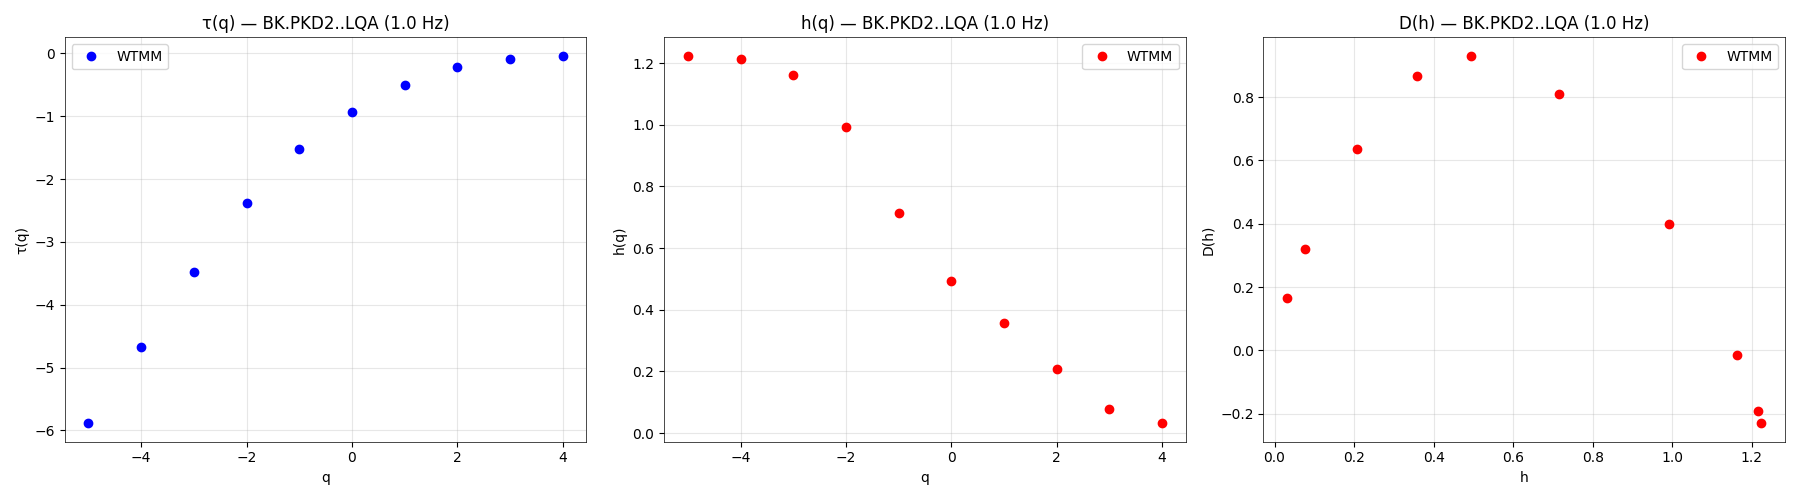


BK.PKD2..LQA (1.0 Hz): no theoretical spectrum available
WTMM h(q) range: [0.0317, 1.2237]


In [51]:
# Cell 19: tau(q), h(q), D(h) spectrum — now imported from wtmm package
from wtmm.spectra import compute_spectra

# Compute spectra
spectra = compute_spectra(pf, log2_a_min=LOG2_A_MIN, log2_a_max=LOG2_A_MAX)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

is_monofractal = has_theory and theory_h is not None and len(theory_h) == 1

# 1. tau(q)
ax = axes[0]
if has_theory:
    ax.plot(theory_q, theory_tau, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('\u03c4(q)')
ax.set_title(f'\u03c4(q) — {analysis_label}')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. h(q)
ax = axes[1]
if has_theory and not is_monofractal:
    ax.plot(theory_q, theory_h, 'k-', label='Theory', linewidth=1)
elif is_monofractal:
    ax.axhline(theory_h[0], color='k', ls='--', lw=1, label=f'Theory h*={theory_h[0]:.3f}')
ax.plot(spectra['q_list'], spectra['h_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title(f'h(q) — {analysis_label}')
ax.legend()
ax.grid(True, alpha=0.3)
if has_theory and not is_monofractal:
    h_pad = 0.15 * (theory_h.max() - theory_h.min())
    ax.set_ylim(theory_h.min() - h_pad, theory_h.max() + h_pad)

# 3. D(h) singularity spectrum
ax = axes[2]
if has_theory and not is_monofractal:
    mask = theory_D > -0.5
    ax.plot(theory_h[mask], theory_D[mask], 'k-', label='Theory', linewidth=1)
elif is_monofractal:
    ax.plot(theory_h[0], theory_D[0], 'k*', markersize=15, label=f'Theory (h*={theory_h[0]:.3f})')
ax.plot(spectra['h_q'], spectra['D_q'], 'ro', markersize=6, linestyle='none', label='WTMM')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')

ax.set_title(f'D(h) — {analysis_label}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison
if has_theory and not is_monofractal:
    from wtmm.spectra import theoretical_devil_staircase
    # Interpolate theory at WTMM q values for comparison
    tau_theory_q = np.interp(spectra['q_list'], theory_q, theory_tau)
    h_theory_q = np.interp(spectra['q_list'], theory_q, theory_h)
    print(f'\n{analysis_label}: theory vs WTMM comparison')
    print(f'h range: [{h_theory_q.min():.3f}, {h_theory_q.max():.3f}]')
    print('\nq\t \u03c4_WTMM\t \u03c4_theory\t diff\t\t h_WTMM\t\t h_theory')
    for i, q_val in enumerate(spectra['q_list']):
        print(f'{q_val:5.1f}\t {spectra["tau_q"][i]:8.4f}\t {tau_theory_q[i]:8.4f}\t {spectra["tau_q"][i]-tau_theory_q[i]:+.4f}'
              f'\t {spectra["h_q"][i]:8.4f}\t {h_theory_q[i]:8.4f}')
elif is_monofractal:
    print(f'\n{analysis_label}: monofractal h* = {theory_h[0]:.4f}')
    print(f'WTMM h(q) range: [{spectra["h_q"].min():.4f}, {spectra["h_q"].max():.4f}]')
    print(f'WTMM h(q) mean:  {spectra["h_q"].mean():.4f}')
else:
    print(f'\n{analysis_label}: no theoretical spectrum available')
    print(f'WTMM h(q) range: [{spectra["h_q"].min():.4f}, {spectra["h_q"].max():.4f}]')


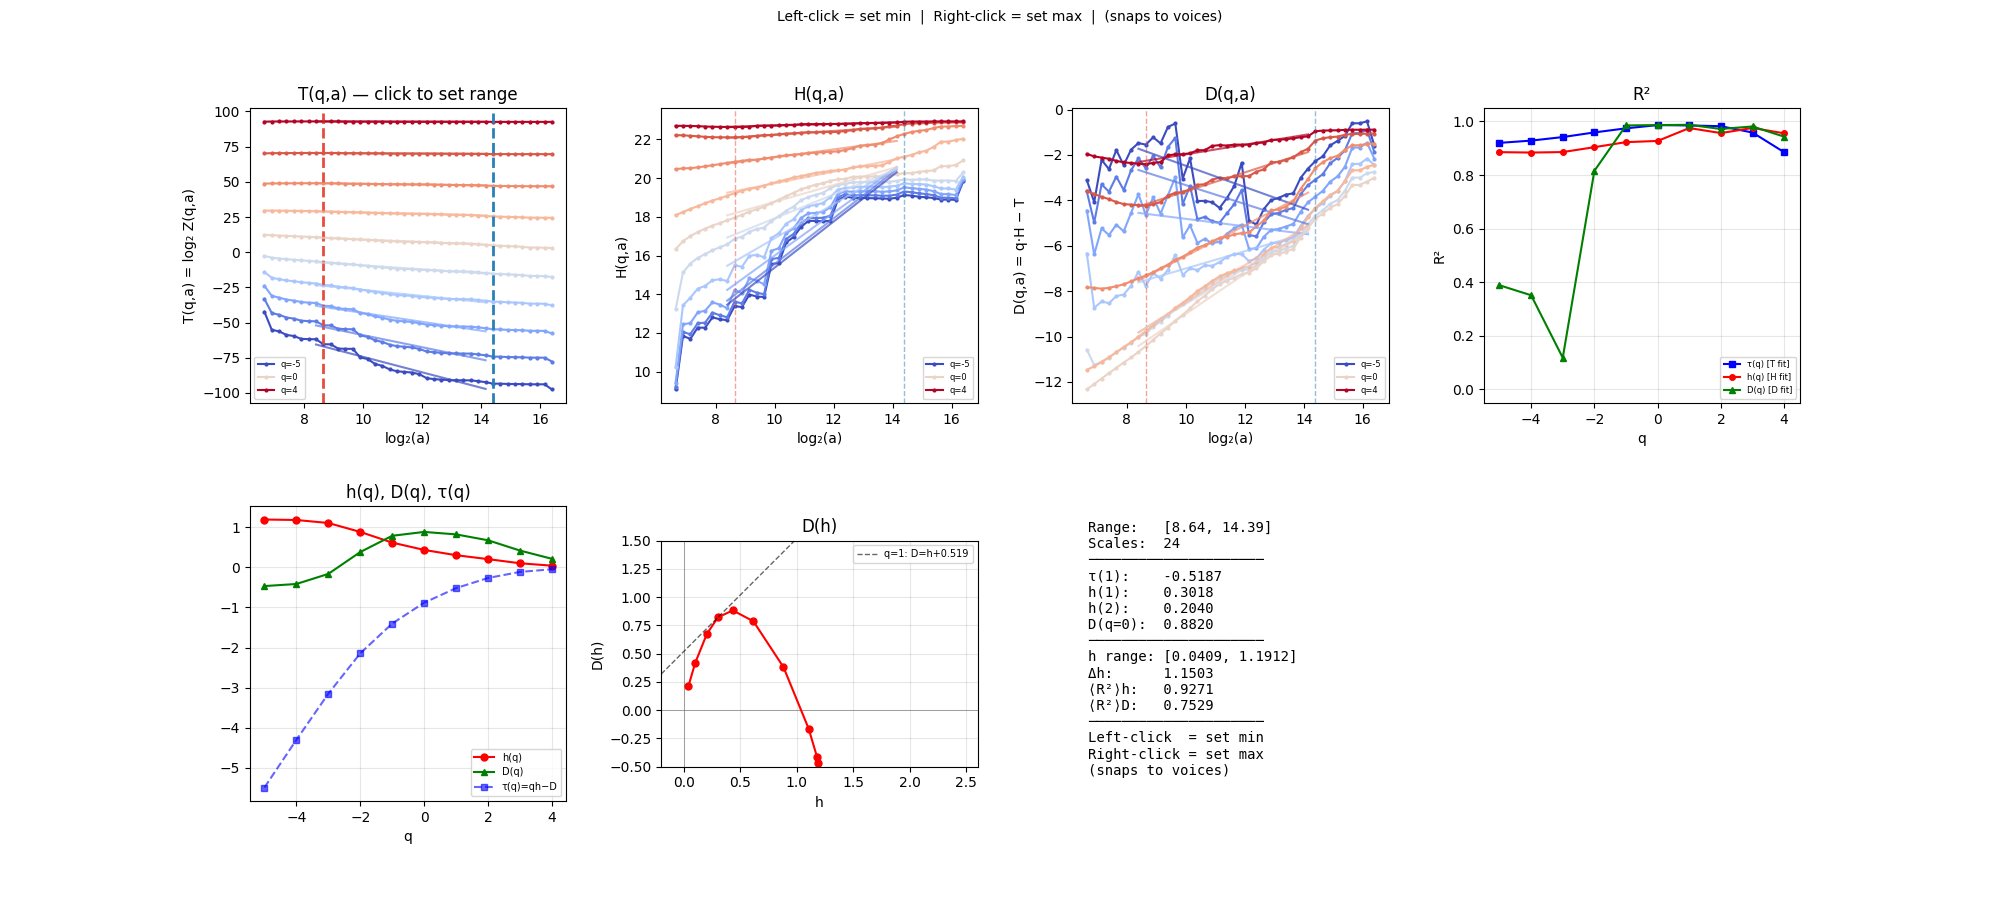

In [52]:
# Interactive scale range selector
# Drag the red/blue vertical lines on the T(q,a) panel to change
# the regression range. Spectra update on mouse release.
# Press 'm' to toggle canonical/microcanonical method.
%matplotlib widget
from wtmm.interactive import interactive_spectra

fig_int, state = interactive_spectra(pf)


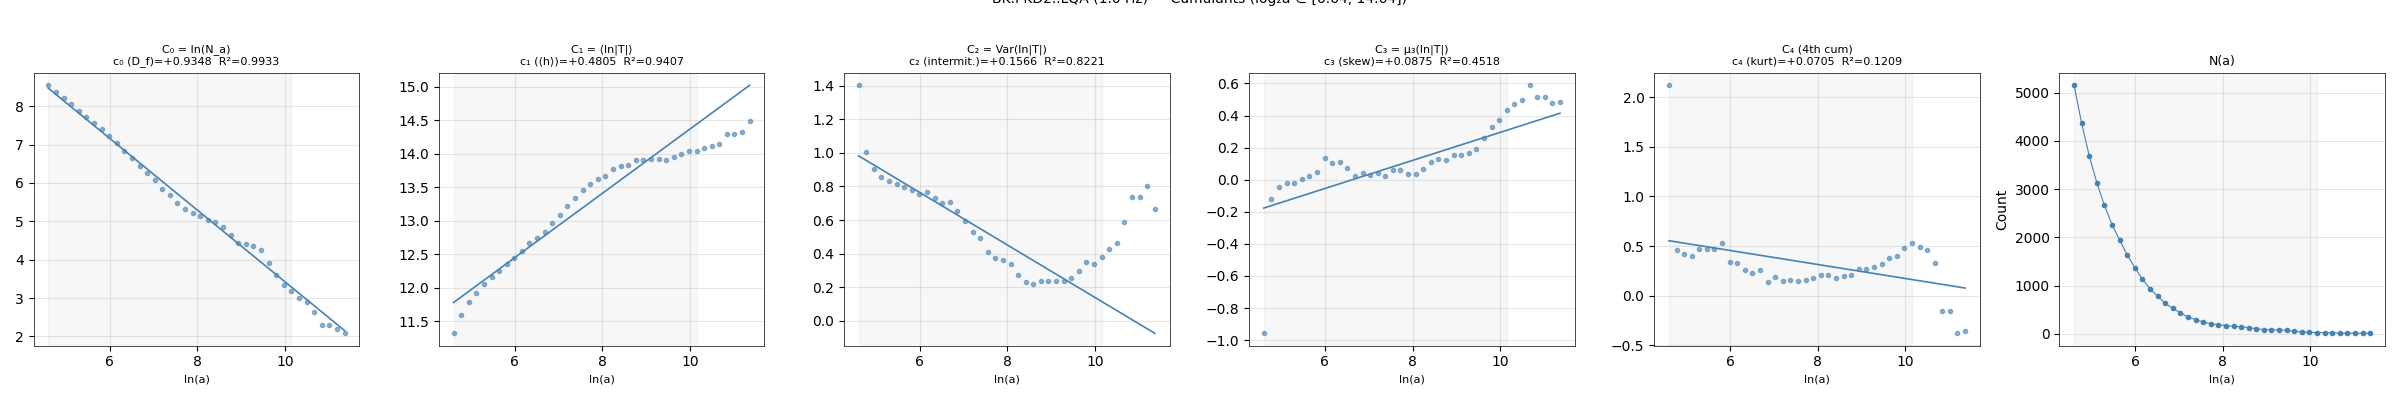

=== Cumulant coefficients ===
                c₀ (D_f) = +0.9348 ± 0.0138   R² = 0.993259
                c₁ (⟨h⟩) = +0.4805 ± 0.0217   R² = 0.940672
          c₂ (intermit.) = +0.1566 ± 0.0131   R² = 0.822062
               c₃ (skew) = +0.0875 ± 0.0173   R² = 0.451837
               c₄ (kurt) = +0.0705 ± 0.0341   R² = 0.120900


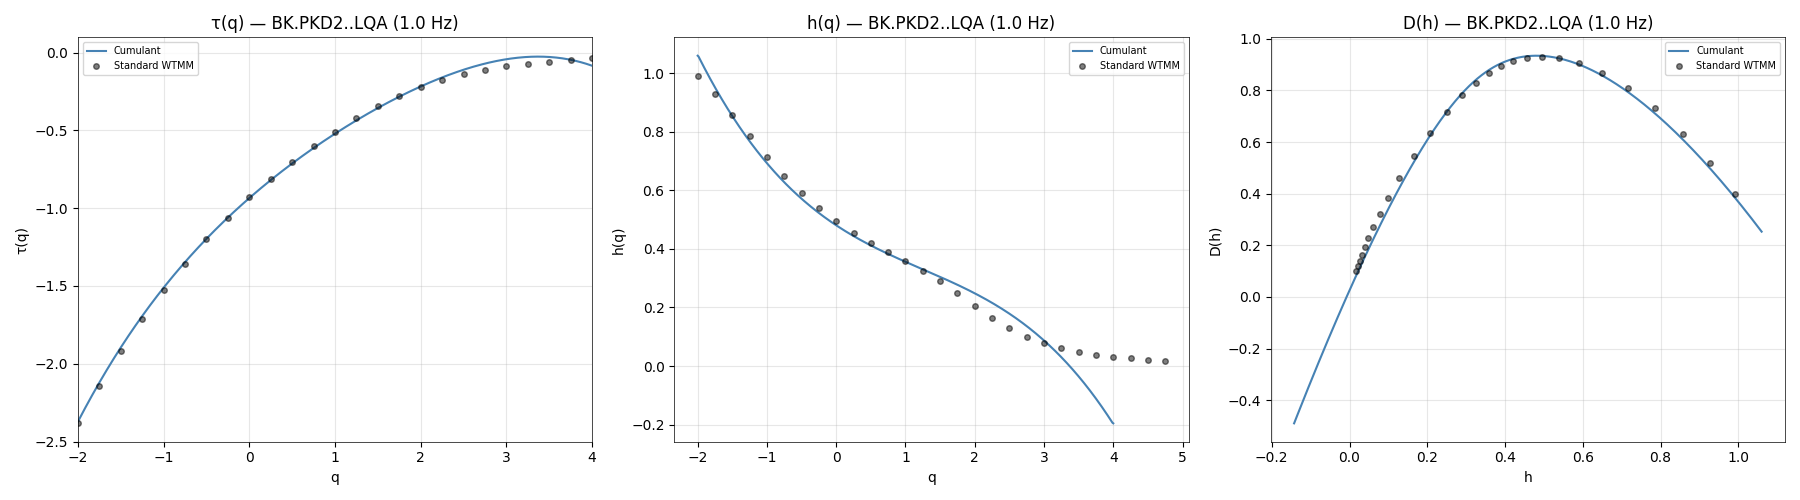


c₃ = +0.0875 → departure from log-normality


In [47]:
# Cumulant analysis — non-truncated only
# τ(q) = -c₀ + c₁q - c₂q²/2! + c₃q³/3! + ...
# cₙ = slope of Cₙ(a) vs ln(a)

Q_RANGE_CUMULANT = (-2, 4)  # valid q range for reconstruction

n_scales = len(extrep_ord)
n_voice_cum = pf['n_voice']
ln_a = np.log(scales[:n_scales])

# --- Compute cumulants C_n(a) at each scale ---
cumulant_names = ['C₀ = ln(N_a)', 'C₁ = ⟨ln|T|⟩', 'C₂ = Var(ln|T|)',
                  'C₃ = μ₃(ln|T|)', 'C₄ (4th cum)']
names_short = ['c₀ (D_f)', 'c₁ (⟨h⟩)', 'c₂ (intermit.)', 'c₃ (skew)', 'c₄ (kurt)']
n_cumulants = len(cumulant_names)
sign_conv = [-1, 1, -1, 1, -1]

C = np.full((n_cumulants, n_scales), np.nan)
N_a = np.zeros(n_scales)

for s in range(n_scales):
    ords = extrep_ord[s]
    N_a[s] = len(ords)
    if len(ords) < 3:
        continue
    ln_T = np.log(np.abs(ords) + 1e-300)
    m1 = np.mean(ln_T)
    d = ln_T - m1
    C[0, s] = np.log(len(ords))
    C[1, s] = m1
    C[2, s] = np.mean(d**2)
    C[3, s] = np.mean(d**3)
    C[4, s] = np.mean(d**4) - 3 * np.mean(d**2)**2

# --- Fit slopes over regression range ---
log2_a0 = np.log2(scales[0])
dx_scale = 1.0 / n_voice_cum
idx_lo = max(int(round((LOG2_A_MIN - log2_a0) / dx_scale)), 0)
idx_hi = min(int(round((LOG2_A_MAX - log2_a0) / dx_scale)), n_scales - 1)
fit_idx = np.arange(idx_lo, idx_hi + 1)
x_fit = ln_a[fit_idx]

c_coeffs = np.zeros(n_cumulants)
c_err = np.zeros(n_cumulants)
c_r2 = np.zeros(n_cumulants)

fig, axes = plt.subplots(1, n_cumulants + 1, figsize=(4 * (n_cumulants + 1), 4))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

for n in range(n_cumulants):
    ax = axes[n]
    valid = np.isfinite(C[n])
    ax.plot(ln_a[valid], C[n, valid], 'o', color='steelblue', markersize=3, alpha=0.6)
    ax.axvspan(ln_a[idx_lo], ln_a[idx_hi], color='gray', alpha=0.06)

    y_fit = C[n, fit_idx]
    fmask = np.isfinite(y_fit)
    if fmask.sum() >= 3:
        slope, intercept = np.polyfit(x_fit[fmask], y_fit[fmask], 1)
        c_coeffs[n] = sign_conv[n] * slope
        y_pred = slope * x_fit[fmask] + intercept
        ss_res = np.sum((y_fit[fmask] - y_pred)**2)
        ss_tot = np.sum((y_fit[fmask] - y_fit[fmask].mean())**2)
        c_r2[n] = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
        n_pts = fmask.sum()
        c_err[n] = np.sqrt(ss_res / max(n_pts - 2, 1) /
                           np.sum((x_fit[fmask] - x_fit[fmask].mean())**2)) if n_pts > 2 else 0
        x_line = np.array([ln_a[valid].min(), ln_a[valid].max()])
        ax.plot(x_line, slope * x_line + intercept, '-', color='steelblue', lw=1.2)

    ax.set_title(f'{cumulant_names[n]}\n{names_short[n]}={c_coeffs[n]:+.4f}  R²={c_r2[n]:.4f}', fontsize=8)
    ax.set_xlabel('ln(a)', fontsize=8)
    ax.grid(True, alpha=0.3)

# N(a) panel
ax = axes[n_cumulants]
ax.plot(ln_a, N_a, 'o-', color='steelblue', markersize=3, lw=0.8)
ax.axvspan(ln_a[idx_lo], ln_a[idx_hi], color='gray', alpha=0.06)
ax.set_title('N(a)', fontsize=9)
ax.set_xlabel('ln(a)', fontsize=8)
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

plt.suptitle(f'{analysis_label} — Cumulants (log₂a ∈ [{LOG2_A_MIN}, {LOG2_A_MAX}])', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# --- Print coefficients ---
print(f'=== Cumulant coefficients ===')
for n in range(n_cumulants):
    print(f'  {names_short[n]:>22s} = {c_coeffs[n]:+.4f} ± {c_err[n]:.4f}   R² = {c_r2[n]:.6f}')

# --- Reconstruct τ(q), h(q), D(h) ---
q_recon = np.linspace(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1], 500)

tau_cum = -c_coeffs[0] + c_coeffs[1]*q_recon - c_coeffs[2]*q_recon**2/2 + c_coeffs[3]*q_recon**3/6 - c_coeffs[4]*q_recon**4/24
h_cum = np.gradient(tau_cum, q_recon)
D_cum = q_recon * h_cum - tau_cum

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# τ(q)
ax = axes[0]
ax.plot(q_recon, tau_cum, '-', color='steelblue', lw=1.5, label='Cumulant')
if has_theory:
    ax.plot(theory_q, theory_tau, 'k-', lw=1, label='Theory')
ax.plot(spectra['q_list'], spectra['tau_q'], 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
ax.set_xlabel('q'); ax.set_ylabel('τ(q)')
ax.set_title(f'τ(q) — {analysis_label}')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.set_xlim(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1])

# h(q)
ax = axes[1]
ax.plot(q_recon, h_cum, '-', color='steelblue', lw=1.5, label='Cumulant')
if has_theory and theory_h is not None and len(theory_h) > 1:
    ax.plot(theory_q, theory_h, 'k-', lw=1, label='Theory')
elif has_theory and theory_h is not None and len(theory_h) == 1:
    ax.axhline(theory_h[0], color='k', ls='--', lw=1, label=f'Theory h*={theory_h[0]:.3f}')
ax.plot(spectra['q_list'], spectra['h_q'], 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
ax.set_xlabel('q'); ax.set_ylabel('h(q)')
ax.set_title(f'h(q) — {analysis_label}')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# D(h)
ax = axes[2]
m = D_cum > -0.5
ax.plot(h_cum[m], D_cum[m], '-', color='steelblue', lw=1.5, label='Cumulant')
if has_theory and theory_h is not None and len(theory_h) > 1:
    tm = theory_D > -0.5
    ax.plot(theory_h[tm], theory_D[tm], 'k-', lw=1, label='Theory')
elif has_theory and theory_h is not None and len(theory_h) == 1:
    ax.plot(theory_h[0], theory_D[0], 'k*', markersize=15, label=f'Theory (h*={theory_h[0]:.3f})')
ax.plot(spectra['h_q'], spectra['D_q'], 'ko', markersize=4, alpha=0.5, linestyle='none', label='Standard WTMM')
ax.set_xlabel('h'); ax.set_ylabel('D(h)')
ax.set_title(f'D(h) — {analysis_label}')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Log-normality check: if c₃ ≈ 0, the cascade is approximately log-normal
if abs(c_coeffs[3]) < 0.01:
    print(f'\nc₃ = {c_coeffs[3]:+.4f} ≈ 0 → approximately log-normal cascade')
else:
    print(f'\nc₃ = {c_coeffs[3]:+.4f} → departure from log-normality')


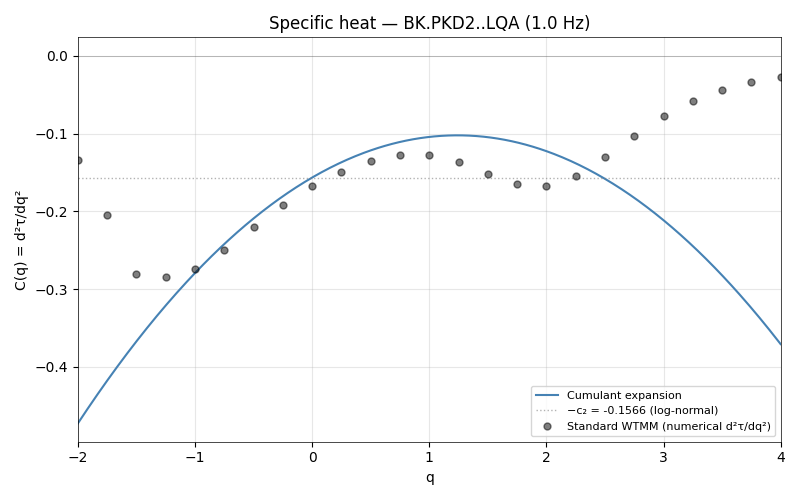

c₂ = 0.1566  →  −c₂ = -0.1566
c₃ = 0.0875  (slope of C(q) at q=0; =0 for log-normal)


In [48]:
# Specific heat C(q) = d²τ/dq²
# From cumulant expansion: C(q) = -c₂ + c₃q - c₄q²/2 + ...
# Monofractal: C(q) = 0 | Log-normal: C(q) = -c₂ (constant) | Phase transition: discontinuity

q_recon_ch = np.linspace(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1], 500)

# Analytical from cumulant coefficients
C_heat_cum = -c_coeffs[2] + c_coeffs[3] * q_recon_ch - c_coeffs[4] * q_recon_ch**2 / 2

# Numerical from standard WTMM τ(q)
q_wtmm = spectra['q_list']
tau_wtmm = spectra['tau_q']
finite = np.isfinite(tau_wtmm)
if finite.sum() >= 3:
    C_heat_wtmm = np.gradient(np.gradient(tau_wtmm[finite], q_wtmm[finite]), q_wtmm[finite])
else:
    C_heat_wtmm = None

fig, ax = plt.subplots(figsize=(8, 5))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

ax.plot(q_recon_ch, C_heat_cum, '-', color='steelblue', lw=1.5, label='Cumulant expansion')
ax.axhline(-c_coeffs[2], color='gray', ls=':', lw=1, alpha=0.6, label=f'−c₂ = {-c_coeffs[2]:.4f} (log-normal)')
ax.axhline(0, color='k', ls='-', lw=0.5, alpha=0.3)

if C_heat_wtmm is not None:
    ax.plot(q_wtmm[finite], C_heat_wtmm, 'ko', markersize=5, alpha=0.5, label='Standard WTMM (numerical d²τ/dq²)')

if has_theory:
    tau_th_fine = np.interp(q_recon_ch, theory_q, theory_tau)
    C_heat_theory = np.gradient(np.gradient(tau_th_fine, q_recon_ch), q_recon_ch)
    ax.plot(q_recon_ch, C_heat_theory, 'k-', lw=1, label='Theory')

ax.set_xlabel('q')
ax.set_ylabel('C(q) = d²τ/dq²')
ax.set_title(f'Specific heat — {analysis_label}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1])
plt.tight_layout()
plt.show()

print(f'c₂ = {c_coeffs[2]:.4f}  →  −c₂ = {-c_coeffs[2]:.4f}')
print(f'c₃ = {c_coeffs[3]:.4f}  (slope of C(q) at q=0; =0 for log-normal)')


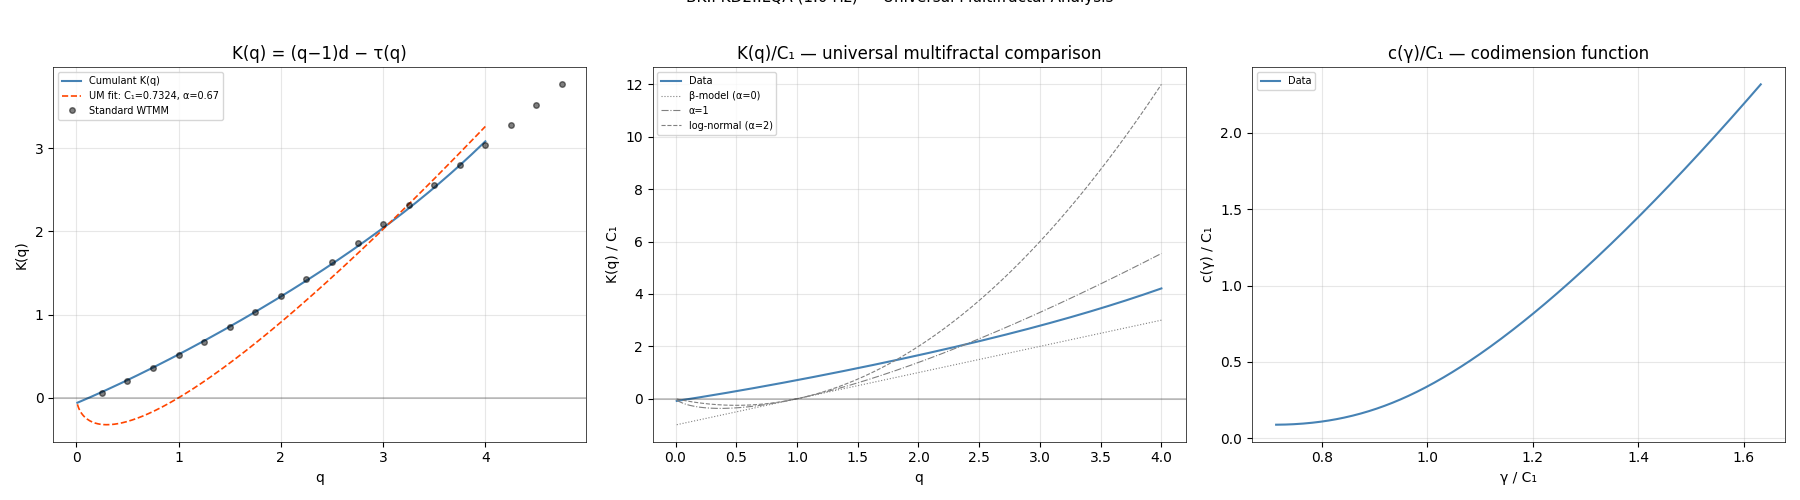

=== Universal Multifractal Parameters ===
  C₁ = 0.7324 ± 0.0404  (intermittency, cf. c₂ = 0.1566)
  α  = 0.672 ± 0.099  (Lévy index, 0=β-model, 2=log-normal)
  → Lévy multifractal with α = 0.67


In [49]:
# Universal Multifractal parameters (C₁, α) from WTMM
# K(q) = (q-1)·d - τ(q),  fit K(q) = C₁/(α-1)·(q^α - q) for α∈(0,2]
# c(γ) = Legendre transform of K(q) = codimension function = d - D(h)

from scipy.optimize import curve_fit

d = 1  # embedding dimension

# --- Compute K(q) from cumulant τ(q) ---
q_K = np.linspace(0.01, Q_RANGE_CUMULANT[1], 300)  # q > 0 for K(q)
tau_cum_K = -c_coeffs[0] + c_coeffs[1]*q_K - c_coeffs[2]*q_K**2/2 + c_coeffs[3]*q_K**3/6 - c_coeffs[4]*q_K**4/24
K_q = (q_K - 1) * d - tau_cum_K

# Also from standard WTMM
q_wtmm = np.array(spectra['q_list'], dtype=float)
tau_wtmm = np.array(spectra['tau_q'], dtype=float)
fmask = np.isfinite(tau_wtmm) & (q_wtmm > 0)
K_wtmm = (q_wtmm[fmask] - 1) * d - tau_wtmm[fmask]

# Theory K(q)
if has_theory:
    q_th_pos = theory_q[theory_q > 0]
    tau_th_pos = np.interp(q_th_pos, theory_q, theory_tau)
    K_theory = (q_th_pos - 1) * d - tau_th_pos

# --- Fit universal multifractal model ---
def K_universal(q, C1, alpha):
    """K(q) = C1/(alpha-1) * (q^alpha - q) for alpha != 1"""
    if abs(alpha - 1.0) < 1e-6:
        return C1 * q * np.log(q)
    return C1 / (alpha - 1) * (q**alpha - q)

# Fit on cumulant K(q) for q > 0.1
fit_mask = q_K > -1.1
try:
    popt, pcov = curve_fit(K_universal, q_K[fit_mask], K_q[fit_mask],
                           p0=[0.1, 1.5], bounds=([1e-6, 0.01], [5.0, 2.0]))
    C1_fit, alpha_fit = popt
    C1_err, alpha_err = np.sqrt(np.diag(pcov))
    K_fit = K_universal(q_K, C1_fit, alpha_fit)
    fit_ok = True
except Exception as e:
    print(f'Fit failed: {e}')
    fit_ok = False

# --- Legendre transform of K(q) → c(γ) ---
# γ = dK/dq,  c(γ) = q·γ - K(q)
dKdq = np.gradient(K_q, q_K)
gamma = dKdq
c_gamma = q_K * gamma - K_q

# Theory c(γ)
if has_theory:
    dK_th = np.gradient(K_theory, q_th_pos)
    gamma_th = dK_th
    c_gamma_th = q_th_pos * gamma_th - K_theory

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Panel 1: K(q) vs q
ax = axes[0]
ax.plot(q_K, K_q, '-', color='steelblue', lw=1.5, label='Cumulant K(q)')
if fit_ok:
    ax.plot(q_K, K_fit, '--', color='orangered', lw=1.2,
            label=f'UM fit: C₁={C1_fit:.4f}, α={alpha_fit:.2f}')
ax.plot(q_wtmm[fmask], K_wtmm, 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
if has_theory:
    ax.plot(q_th_pos, K_theory, 'k-', lw=1, label='Theory')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q'); ax.set_ylabel('K(q)')
ax.set_title('K(q) = (q−1)d − τ(q)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Panel 2: K(q)/C₁ vs q (normalized, like Lovejoy Fig 13)
ax = axes[1]
if fit_ok and C1_fit > 1e-8:
    ax.plot(q_K, K_q / C1_fit, '-', color='steelblue', lw=1.5, label='Data')
    # Reference curves for α = 0, 1, 2
    for a_ref, ls, lbl in [(0.0, ':', 'β-model (α=0)'),
                            (1.0, '-.', 'α=1'),
                            (2.0, '--', 'log-normal (α=2)')]:
        K_ref = K_universal(q_K, C1_fit, a_ref) / C1_fit
        ax.plot(q_K, K_ref, ls, color='gray', lw=0.8, label=lbl)
    ax.set_ylabel('K(q) / C₁')
else:
    ax.plot(q_K, K_q, '-', color='steelblue', lw=1.5)
    ax.set_ylabel('K(q)')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q')
ax.set_title('K(q)/C₁ — universal multifractal comparison')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Panel 3: c(γ)/C₁ vs γ/C₁ (codimension, like Lovejoy Fig 14)
ax = axes[2]
if fit_ok and C1_fit > 1e-8:
    ax.plot(gamma / C1_fit, c_gamma / C1_fit, '-', color='steelblue', lw=1.5, label='Data')
    if has_theory:
        ax.plot(gamma_th / C1_fit, c_gamma_th / C1_fit, 'k-', lw=1, label='Theory')
    ax.set_xlabel('γ / C₁'); ax.set_ylabel('c(γ) / C₁')
else:
    ax.plot(gamma, c_gamma, '-', color='steelblue', lw=1.5, label='Data')
    if has_theory:
        ax.plot(gamma_th, c_gamma_th, 'k-', lw=1, label='Theory')
    ax.set_xlabel('γ'); ax.set_ylabel('c(γ)')
ax.set_title('c(γ)/C₁ — codimension function')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle(f'{analysis_label} — Universal Multifractal Analysis', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# --- Summary ---
if fit_ok:
    print(f'=== Universal Multifractal Parameters ===')
    print(f'  C₁ = {C1_fit:.4f} ± {C1_err:.4f}  (intermittency, cf. c₂ = {c_coeffs[2]:.4f})')
    print(f'  α  = {alpha_fit:.3f} ± {alpha_err:.3f}  (Lévy index, 0=β-model, 2=log-normal)')
    if alpha_fit > 1.8:
        print(f'  → Near log-normal (α ≈ 2)')
    elif alpha_fit < 0.2:
        print(f'  → Near β-model (α ≈ 0)')
    else:
        print(f'  → Lévy multifractal with α = {alpha_fit:.2f}')
